In [1]:
# =============================================================================
# PARAMETERS — imports, constants, paths
# =============================================================================
import os
import glob
import warnings

warnings.filterwarnings("ignore", category=FutureWarning, module="pyresample")

import numpy as np
import h5py
import matplotlib.pyplot as plt
import rasterio
from rasterio.transform import from_bounds
from rasterio.warp import reproject, Resampling
from rasterio.merge import merge
from rasterio.windows import Window, from_bounds as window_from_bounds, transform as window_transform
from pyproj import CRS, Transformer

try:
    from pyresample import geometry, image
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyresample"])
    from pyresample import geometry, image

# -----------------------------------------------------------------------------
# Matplotlib backend — try widget for interactivity, fallback to inline
# -----------------------------------------------------------------------------
try:
    import ipympl
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    try:
        get_ipython().run_line_magic("matplotlib", "inline")
    except Exception:
        pass

# -----------------------------------------------------------------------------
# Project root — cwd if run from project root, else parent of notebooks/
# -----------------------------------------------------------------------------
_cwd = os.getcwd()
PROJECT_ROOT = os.path.normpath(os.path.join(_cwd, "..")) if os.path.basename(_cwd) == "notebooks" else _cwd

# -----------------------------------------------------------------------------
# Paths (relative to project root)
# -----------------------------------------------------------------------------
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

VIIRS_DIR = os.path.join(PROJECT_ROOT, "data", "viirs")
_h5_files = glob.glob(os.path.join(VIIRS_DIR, "*.h5"))

if _h5_files:
    HDF5_PATH = _h5_files[0]
    if len(_h5_files) > 1:
        print(f"Multiple HDF5 files found; using: {HDF5_PATH}")
else:
    HDF5_PATH = os.path.join(VIIRS_DIR, "GITCO-SVI01-SVI02-SVI03-SVI04-SVI05_npp_d20260125_t2315015_e2320401_b73826_c20260127210812288114_oeac_ops.h5")
    print(f"No HDF5 in data/viirs/; will use path: {HDF5_PATH}")

OCC_GLOB = os.path.join(PROJECT_ROOT, "data", "gsw", "occurrence_alaska_tiles", "occurrence_*_*.tif")
SEA_GLOB = os.path.join(PROJECT_ROOT, "data", "gsw", "seasonality_alaska_tiles", "seasonality_*_*.tif")

# -----------------------------------------------------------------------------
# AOI and resolution
# -----------------------------------------------------------------------------
AOI_BBOX = (54, 72, -171, -129)  # lat_min, lat_max, lon_min, lon_max
RESOLUTION_M = 375.0
RESOLUTION_30M = 30.0
PAD_30M = 30.0  # pad extent by one 30m pixel on all sides
N_PIXELS_LAND = 1
N_PIXELS_MIXED = 5
N_PIXELS_WATER = 3

# -----------------------------------------------------------------------------
# Chunking controls (memory-safe mode; logic remains unchanged)
# -----------------------------------------------------------------------------
USE_AOI_CHUNKING = True
CHUNK_SPLIT_LAT = 2
CHUNK_SPLIT_LON = 1
CHUNK_OVERLAP_KM = 1.0
CHUNK_TMP_DIR = os.path.join(OUTPUT_DIR, "chunks_tmp")
os.makedirs(CHUNK_TMP_DIR, exist_ok=True)



In [2]:
# =============================================================================
# PREFLIGHT — AOI memory check (sandbox test before full pipeline)
# =============================================================================
# Estimates 30m crop size and memory. No heavy data loaded. Run this cell first
# to verify your AOI is within limits before running DATA LOADING.

import math
MAX_PIXELS = 80_000_000  # same as load_jrc_crop_safe

lat_min, lat_max, lon_min, lon_max = AOI_BBOX
lat_span = lat_max - lat_min
lon_span = lon_max - lon_min
lat_center = 0.5 * (lat_min + lat_max)

# Approximate meters: 1 deg lat ~ 111 km; 1 deg lon ~ 111 * cos(lat) km
m_per_deg_lat = 111_000
m_per_deg_lon = 111_000 * math.cos(math.radians(lat_center))
lat_m = lat_span * m_per_deg_lat
lon_m = lon_span * m_per_deg_lon

# Full AOI 30m pixels
n_cols_30m = int(math.ceil(lon_m / RESOLUTION_30M))
n_rows_30m = int(math.ceil(lat_m / RESOLUTION_30M))
n_pix_30m = n_rows_30m * n_cols_30m

# 375m pixels (for reference)
n_cols_375m = int(math.ceil(lon_m / RESOLUTION_M))
n_rows_375m = int(math.ceil(lat_m / RESOLUTION_M))
n_pix_375m = n_rows_375m * n_cols_375m

# Rough memory: occurrence/seasonality uint8 = 1 B/px; float32 = 4 B/px
# Per product: 1 + 4 bytes (uint8 crop + float32) ~ 5 B/px. Two products = 10 B/px.
mem_mb_30m = n_pix_30m * 10 / (1024 * 1024)

# Chunk estimate
n_lat_chunks = CHUNK_SPLIT_LAT if USE_AOI_CHUNKING else 1
n_lon_chunks = CHUNK_SPLIT_LON if USE_AOI_CHUNKING else 1
n_chunks = max(1, n_lat_chunks * n_lon_chunks)
chunk_pix_est = int(math.ceil(n_pix_30m / n_chunks))
chunk_mem_mb_est = chunk_pix_est * 10 / (1024 * 1024)

print("PREFLIGHT — AOI memory check")
print("-" * 60)
print(f"AOI: lat [{lat_min}, {lat_max}], lon [{lon_min}, {lon_max}]")
print(f"Span: {lat_span:.2f}° lat x {lon_span:.2f}° lon")
print(f"Full 30m crop: ~{n_rows_30m} x {n_cols_30m} = {n_pix_30m:,} pixels")
print(f"Full 375m grid: ~{n_rows_375m} x {n_cols_375m} = {n_pix_375m:,} pixels")
print(f"Est. full memory (30m products): ~{mem_mb_30m:.0f} MB")

if USE_AOI_CHUNKING:
    print(f"Chunking: enabled ({n_lat_chunks}x{n_lon_chunks}, overlap={CHUNK_OVERLAP_KM:.1f} km)")
    print(f"Est. per-chunk 30m pixels: ~{chunk_pix_est:,}")
    print(f"Est. per-chunk memory (30m products): ~{chunk_mem_mb_est:.0f} MB")
    if chunk_pix_est > MAX_PIXELS:
        print(f"WARNING: per-chunk {chunk_pix_est:,} > {MAX_PIXELS:,} max. Increase chunk count.")
    else:
        print(f"OK: per-chunk under {MAX_PIXELS:,} pixel limit.")
else:
    if n_pix_30m > MAX_PIXELS:
        print(f"WARNING: {n_pix_30m:,} > {MAX_PIXELS:,} max. Reduce AOI or enable chunking.")
    else:
        print(f"OK: under {MAX_PIXELS:,} pixel limit.")
print("-" * 60)



PREFLIGHT — AOI memory check
------------------------------------------------------------
AOI: lat [54, 72], lon [-171, -129]
Span: 18.00° lat x 42.00° lon
Full 30m crop: ~66600 x 70551 = 4,698,696,600 pixels
Full 375m grid: ~5328 x 5645 = 30,076,560 pixels
Est. full memory (30m products): ~44810 MB
Chunking: enabled (2x1, overlap=1.0 km)
Est. per-chunk 30m pixels: ~2,349,348,300
Est. per-chunk memory (30m products): ~22405 MB
------------------------------------------------------------


In [3]:
# =============================================================================
# HELPERS — all functions, no execution
# =============================================================================

def discover_viirs_paths(h5):
    """Find Latitude, Longitude, and I1–I5 band paths in VIIRS GITCO/SVI HDF5."""
    def list_datasets(obj, prefix=""):
        paths = []
        for key in obj.keys():
            p = f"{prefix}/{key}" if prefix else key
            if isinstance(obj[key], h5py.Dataset):
                paths.append(p)
            else:
                paths.extend(list_datasets(obj[key], p))
        return paths
    datasets = list_datasets(h5)
    paths = {}
    for kind in ["Latitude", "Longitude"]:
        cand = [p for p in datasets if "GEO" in p and kind in p]
        if not cand:
            cand = [p for p in datasets if "GITCO" in p and kind in p]
        if cand:
            paths[kind.lower()] = cand[0]
    if "latitude" not in paths or "longitude" not in paths:
        raise KeyError("Could not find Latitude/Longitude in HDF5")
    for band in range(1, 6):
        token = f"VIIRS-I{band}-SDR_All"
        names = ["Reflectance", "Radiance"] if band <= 3 else ["BrightnessTemperature", "Radiance"]
        for name in names:
            cand = [p for p in datasets if token in p and p.endswith(name)]
            if cand:
                paths[f"I{band}"] = cand[0]
                break
        if f"I{band}" not in paths:
            raise KeyError(f"Could not find I{band} dataset")
    return paths


def discover_band_scaling(h5, band_path):
    """Get scale/offset from band attrs or companion *Factors dataset."""
    result = {"scale": None, "offset": None, "fill_value": None, "valid_range": None}
    attrs = h5[band_path].attrs
    for k, v in attrs.items():
        kk = k.lower()
        if "scale" in kk or kk == "scalefactor":
            result["scale"] = float(np.asarray(v).ravel()[0])
        elif "offset" in kk or kk == "addoffset":
            result["offset"] = float(np.asarray(v).ravel()[0])
        elif "fill" in kk:
            result["fill_value"] = float(np.asarray(v).ravel()[0])
        elif "valid" in kk and "range" in kk:
            arr = np.asarray(v).ravel()
            if arr.size >= 2:
                result["valid_range"] = (float(arr[0]), float(arr[1]))
    parts = band_path.split("/")
    factors_path = "/".join(parts[:-1]) + "/" + parts[-1] + "Factors"
    if factors_path in h5 and isinstance(h5[factors_path], h5py.Dataset):
        fac = np.asarray(h5[factors_path][...]).ravel()
        if result["scale"] is None and len(fac) >= 1:
            result["scale"] = float(fac[0])
        if result["offset"] is None and len(fac) >= 2:
            result["offset"] = float(fac[1])
    return result


def apply_band_scaling(raw, scaling):
    """Apply scale/offset, mask fill and invalid. Returns float32."""
    out = raw.astype(np.float32, copy=True)
    mask_invalid = (out == 63999) | (out == 65533) | (out > 65529)
    out[mask_invalid] = np.nan
    if scaling.get("fill_value") is not None:
        out[out == scaling["fill_value"]] = np.nan
    if scaling.get("valid_range") is not None:
        vmin, vmax = scaling["valid_range"]
        out[(out < vmin) | (out > vmax)] = np.nan
    s, o = scaling.get("scale"), scaling.get("offset")
    if s is not None and o is not None:
        out = out * s + o
    elif s is not None:
        out = out * s
    elif o is not None:
        out = out + o
    return out


def load_viirs_swath(hdf5_path):
    """Load lat, lon, and scaled I1–I5 from VIIRS HDF5."""
    hdf5_path = os.path.expanduser(hdf5_path)
    if not os.path.exists(hdf5_path):
        raise FileNotFoundError(f"HDF5 not found: {hdf5_path}")
    with h5py.File(hdf5_path, "r") as h5:
        paths = discover_viirs_paths(h5)
        lat = h5[paths["latitude"]][...].astype(np.float32)
        lon = h5[paths["longitude"]][...].astype(np.float32)
        lat[(lat < -90) | (lat > 90)] = np.nan
        lon[(lon < -180) | (lon > 180)] = np.nan
        bands = {}
        for i in range(1, 6):
            bp = paths[f"I{i}"]
            raw = h5[bp][...]
            scaling = discover_band_scaling(h5, bp)
            bands[f"I{i}"] = apply_band_scaling(raw, scaling)
    return lat, lon, bands


def bbox_intersects(bounds, aoi_bbox):
    """bounds: (left, bottom, right, top) in EPSG:4326."""
    left, bottom, right, top = bounds
    lat_min, lat_max, lon_min, lon_max = aoi_bbox
    aoi_left, aoi_bottom, aoi_right, aoi_top = lon_min, lat_min, lon_max, lat_max
    return not (right < aoi_left or left > aoi_right or top < aoi_bottom or bottom > aoi_top)


def find_jrc_tiles_for_aoi(aoi_bbox, tile_glob):
    paths = sorted(glob.glob(tile_glob))
    if not paths:
        raise FileNotFoundError(f"No JRC tiles found at: {tile_glob}")
    hit = []
    for p in paths:
        with rasterio.open(p) as src:
            if src.crs is not None and bbox_intersects(src.bounds, aoi_bbox):
                hit.append(p)
    if not hit:
        raise FileNotFoundError(f"No JRC tiles intersect AOI_BBOX. Tiles: {len(paths)}")
    return hit


def load_jrc_crop_safe(aoi_bbox, tile_glob, max_pixels=80_000_000):
    """RAM-safe: merge with bounds= to crop during merge."""
    lat_min, lat_max, lon_min, lon_max = aoi_bbox
    west, south, east, north = lon_min, lat_min, lon_max, lat_max
    lat_span = lat_max - lat_min
    lon_span = lon_max - lon_min
    if lat_span > 10 or lon_span > 25:
        raise ValueError(
            f"AOI too large ({lat_span:.1f}° lat x {lon_span:.1f}° lon). "
            "Use smaller AOI (few degrees)."
        )
    tile_paths = find_jrc_tiles_for_aoi(aoi_bbox, tile_glob)
    srcs = [rasterio.open(p) for p in tile_paths]
    try:
        crs = srcs[0].crs
        if crs is None:
            raise ValueError("JRC tiles have no CRS. Re-export with EPSG:4326.")
        mosaic, mosaic_transform = merge(srcs, bounds=(west, south, east, north))
        arr = mosaic[0].astype(np.uint8)
        n_pix = int(arr.shape[0]) * int(arr.shape[1])
        if n_pix > max_pixels:
            raise MemoryError(f"Crop too large: {n_pix:,} pixels. Reduce AOI.")
        return arr, (west, south, east, north), crs
    finally:
        for s in srcs:
            s.close()


def choose_utm_crs(lon0, lat0):
    zone = int((lon0 + 180) / 6) + 1
    epsg = 32600 + zone if lat0 >= 0 else 32700 + zone
    return CRS.from_epsg(epsg)


def swath_to_grid(lat, lon, values, dst_crs, dst_res_m, bbox_latlon):
    if geometry is None or image is None:
        raise ImportError("pyresample required")
    lat_min, lat_max, lon_min, lon_max = bbox_latlon
    trans_to_utm = Transformer.from_crs("EPSG:4326", dst_crs, always_xy=True)
    buf = 0.5
    in_aoi = (lat >= lat_min - buf) & (lat <= lat_max + buf) & (lon >= lon_min - buf) & (lon <= lon_max + buf)
    valid = np.isfinite(lat) & np.isfinite(lon) & np.isfinite(values) & in_aoi
    if not np.any(valid):
        corners_ll = [(lon_min, lat_min), (lon_max, lat_min), (lon_max, lat_max), (lon_min, lat_max)]
        corners_utm = [trans_to_utm.transform(x, y) for x, y in corners_ll]
        x_min, x_max = min(c[0] for c in corners_utm), max(c[0] for c in corners_utm)
        y_min, y_max = min(c[1] for c in corners_utm), max(c[1] for c in corners_utm)
        width = max(1, int(np.ceil((x_max - x_min) / dst_res_m)))
        height = max(1, int(np.ceil((y_max - y_min) / dst_res_m)))
        transform = from_bounds(x_min, y_min, x_max, y_max, width, height)
        return np.full((height, width), np.nan, dtype=np.float32), transform
    lats_v = lat[valid].astype(np.float32, copy=False)
    lons_v = lon[valid].astype(np.float32, copy=False)
    data_v = values[valid].astype(np.float32, copy=False)
    corners_ll = [(lon_min, lat_min), (lon_max, lat_min), (lon_max, lat_max), (lon_min, lat_max)]
    corners_utm = [trans_to_utm.transform(x, y) for x, y in corners_ll]
    x_min, x_max = min(c[0] for c in corners_utm), max(c[0] for c in corners_utm)
    y_min, y_max = min(c[1] for c in corners_utm), max(c[1] for c in corners_utm)
    width = max(1, int(np.ceil((x_max - x_min) / dst_res_m)))
    height = max(1, int(np.ceil((y_max - y_min) / dst_res_m)))
    area_extent = (x_min, y_min, x_max, y_max)
    lon0, lat0 = 0.5 * (lon_min + lon_max), 0.5 * (lat_min + lat_max)
    zone = int((lon0 + 180) / 6) + 1
    proj_dict = {"proj": "utm", "zone": zone, "ellps": "WGS84", "units": "m"}
    area_def = geometry.AreaDefinition("viirs_utm", "VIIRS UTM", "viirs_utm", proj_dict, width, height, area_extent)
    swath_def = geometry.SwathDefinition(lons=lons_v, lats=lats_v)
    swath_con = image.ImageContainerNearest(data_v, swath_def, radius_of_influence=7000, epsilon=0.375, nprocs=1)
    area_con = swath_con.resample(area_def)
    arr = area_con.image_data
    result = np.ma.filled(arr, fill_value=np.nan).astype(np.float32) if np.ma.is_masked(arr) else np.asarray(arr, dtype=np.float32)
    transform = from_bounds(x_min, y_min, x_max, y_max, width, height)
    return result, transform


def reproject_to_utm_30m(src_data, src_bounds, src_crs, dst_crs, res_m=30, resampling=Resampling.bilinear, target_extent=None, pad_m=0):
    """Reproject to UTM 30m. If target_extent given, pad by pad_m on all sides."""
    west, south, east, north = src_bounds
    if target_extent is not None:
        x_min, y_min, x_max, y_max = target_extent
        if pad_m > 0:
            x_min -= pad_m
            y_min -= pad_m
            x_max += pad_m
            y_max += pad_m
    else:
        trans = Transformer.from_crs(src_crs, dst_crs, always_xy=True)
        corners_ll = [(west, south), (east, south), (east, north), (west, north)]
        corners_utm = [trans.transform(x, y) for x, y in corners_ll]
        x_min, x_max = min(c[0] for c in corners_utm), max(c[0] for c in corners_utm)
        y_min, y_max = min(c[1] for c in corners_utm), max(c[1] for c in corners_utm)
    width = max(1, int(np.ceil((x_max - x_min) / res_m)))
    height = max(1, int(np.ceil((y_max - y_min) / res_m)))
    dst_transform = from_bounds(x_min, y_min, x_max, y_max, width, height)
    src_transform = from_bounds(west, south, east, north, src_data.shape[1], src_data.shape[0])
    src_nan = np.where(np.isfinite(src_data), src_data, np.nan)
    dst_data = np.full((height, width), np.nan, dtype=np.float32)
    reproject(source=src_nan, destination=dst_data, src_transform=src_transform, src_crs=src_crs,
             src_nodata=np.nan, dst_transform=dst_transform, dst_crs=dst_crs, dst_nodata=np.nan, resampling=resampling)
    return dst_data, dst_transform


def _assert_north_up(transform, name="transform"):
    """Assert transform has no rotation (north-up raster)."""
    b, d = transform.b, transform.d
    if abs(b) >= 1e-9 or abs(d) >= 1e-9:
        raise ValueError(
            f"{name} has rotation (b={b}, d={d}). "
            "Area-weighted rectangle overlap requires north-up rasters. Use shapely for rotated rasters."
        )


def aggregate_area_weighted_rectangles(data_30m, tf_30m, tf_375m, shape_375m):
    """
    Area-weighted aggregation of 30m water fraction to 375m grid using exact rectangle overlap.
    Numerator: sum(value_i * overlap_frac_i) for finite 30m pixels only.
    Denominator: sum(overlap_frac_i) over ALL intersecting 30m pixels (including nodata).
    wf_375 = weighted_water / total_overlap. North-up rasters only.
    """
    _assert_north_up(tf_30m, "tf_30m")
    _assert_north_up(tf_375m, "tf_375m")

    area_30m_px = abs(tf_30m.a) * abs(tf_30m.e)
    out = np.full(shape_375m, np.nan, dtype=np.float32)
    nrows, ncols = shape_375m

    for r in range(nrows):
        for c in range(ncols):
            # 375m pixel bounds (left, bottom, right, top) in UTM
            x_ul = tf_375m.c + c * tf_375m.a
            y_ul = tf_375m.f + r * tf_375m.e
            x_lr = tf_375m.c + (c + 1) * tf_375m.a
            y_lr = tf_375m.f + (r + 1) * tf_375m.e
            l_375 = min(x_ul, x_lr)
            r_375 = max(x_ul, x_lr)
            b_375 = min(y_ul, y_lr)
            t_375 = max(y_ul, y_lr)

            win = window_from_bounds(l_375, b_375, r_375, t_375, transform=tf_30m)
            col_off = int(max(0, win.col_off))
            row_off = int(max(0, win.row_off))
            w = int(win.width)
            h = int(win.height)
            col_end = min(col_off + w, data_30m.shape[1])
            row_end = min(row_off + h, data_30m.shape[0])

            weighted_water = 0.0
            total_overlap = 0.0

            for j in range(col_off, col_end):
                for i in range(row_off, row_end):
                    # 30m pixel bounds
                    x_ul_30 = tf_30m.c + j * tf_30m.a
                    y_ul_30 = tf_30m.f + i * tf_30m.e
                    x_lr_30 = tf_30m.c + (j + 1) * tf_30m.a
                    y_lr_30 = tf_30m.f + (i + 1) * tf_30m.e
                    l_30 = min(x_ul_30, x_lr_30)
                    r_30 = max(x_ul_30, x_lr_30)
                    b_30 = min(y_ul_30, y_lr_30)
                    t_30 = max(y_ul_30, y_lr_30)

                    overlap_w = max(0, min(r_375, r_30) - max(l_375, l_30))
                    overlap_h = max(0, min(t_375, t_30) - max(b_375, b_30))
                    overlap_area = overlap_w * overlap_h
                    overlap_fraction = overlap_area / area_30m_px

                    total_overlap += overlap_fraction
                    val = data_30m[i, j]
                    if np.isfinite(val):
                        weighted_water += val * overlap_fraction

            if total_overlap > 0:
                out[r, c] = weighted_water / total_overlap

    return out


def inspect_375m_pixel_area_weighted(r, c, data_30m, data_375m, tf_30m, tf_375m):
    """Verify single 375m pixel using same rectangle overlap logic."""
    _assert_north_up(tf_30m, "tf_30m")
    _assert_north_up(tf_375m, "tf_375m")

    area_30m_px = abs(tf_30m.a) * abs(tf_30m.e)
    x_ul = tf_375m.c + c * tf_375m.a
    y_ul = tf_375m.f + r * tf_375m.e
    x_lr = tf_375m.c + (c + 1) * tf_375m.a
    y_lr = tf_375m.f + (r + 1) * tf_375m.e
    l_375 = min(x_ul, x_lr)
    r_375 = max(x_ul, x_lr)
    b_375 = min(y_ul, y_lr)
    t_375 = max(y_ul, y_lr)

    win = window_from_bounds(l_375, b_375, r_375, t_375, transform=tf_30m)
    col_off = int(max(0, win.col_off))
    row_off = int(max(0, win.row_off))
    w = int(win.width)
    h = int(win.height)
    col_end = min(col_off + w, data_30m.shape[1])
    row_end = min(row_off + h, data_30m.shape[0])

    weighted_water = 0.0
    total_overlap = 0.0

    for j in range(col_off, col_end):
        for i in range(row_off, row_end):
            x_ul_30 = tf_30m.c + j * tf_30m.a
            y_ul_30 = tf_30m.f + i * tf_30m.e
            x_lr_30 = tf_30m.c + (j + 1) * tf_30m.a
            y_lr_30 = tf_30m.f + (i + 1) * tf_30m.e
            l_30 = min(x_ul_30, x_lr_30)
            r_30 = max(x_ul_30, x_lr_30)
            b_30 = min(y_ul_30, y_lr_30)
            t_30 = max(y_ul_30, y_lr_30)

            overlap_w = max(0, min(r_375, r_30) - max(l_375, l_30))
            overlap_h = max(0, min(t_375, t_30) - max(b_375, b_30))
            overlap_area = overlap_w * overlap_h
            overlap_fraction = overlap_area / area_30m_px

            total_overlap += overlap_fraction
            val = data_30m[i, j]
            if np.isfinite(val):
                weighted_water += val * overlap_fraction

    recomputed = (weighted_water / total_overlap) if total_overlap > 0 else np.nan
    stored = float(data_375m[r, c]) if np.isfinite(data_375m[r, c]) else np.nan
    return recomputed, stored, total_overlap



In [4]:
# =============================================================================
# HOTFIX — memory-safe reproject_to_utm_30m (no duplicate source array)
# =============================================================================
def reproject_to_utm_30m(src_data, src_bounds, src_crs, dst_crs, res_m=30, resampling=Resampling.bilinear, target_extent=None, pad_m=0):
    """Reproject to UTM 30m. If target_extent given, pad by pad_m on all sides."""
    west, south, east, north = src_bounds
    if target_extent is not None:
        x_min, y_min, x_max, y_max = target_extent
        if pad_m > 0:
            x_min -= pad_m
            y_min -= pad_m
            x_max += pad_m
            y_max += pad_m
    else:
        trans = Transformer.from_crs(src_crs, dst_crs, always_xy=True)
        corners_ll = [(west, south), (east, south), (east, north), (west, north)]
        corners_utm = [trans.transform(x, y) for x, y in corners_ll]
        x_min, x_max = min(c[0] for c in corners_utm), max(c[0] for c in corners_utm)
        y_min, y_max = min(c[1] for c in corners_utm), max(c[1] for c in corners_utm)

    width = max(1, int(np.ceil((x_max - x_min) / res_m)))
    height = max(1, int(np.ceil((y_max - y_min) / res_m)))
    dst_transform = from_bounds(x_min, y_min, x_max, y_max, width, height)
    src_transform = from_bounds(west, south, east, north, src_data.shape[1], src_data.shape[0])

    src_arr = np.asarray(src_data, dtype=np.float32)
    dst_data = np.full((height, width), np.nan, dtype=np.float32)

    reproject(
        source=src_arr,
        destination=dst_data,
        src_transform=src_transform,
        src_crs=src_crs,
        src_nodata=np.nan,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        dst_nodata=np.nan,
        resampling=resampling,
    )
    return dst_data, dst_transform


In [5]:
# =============================================================================
# CHUNKING HELPERS — split AOI, trim overlap cores, merge rasters
# =============================================================================

def _km_to_deg_lat(km):
    return km / 111.0


def _km_to_deg_lon(km, lat_deg):
    cos_lat = max(1e-6, np.cos(np.radians(lat_deg)))
    return km / (111.0 * cos_lat)


def split_aoi_with_overlap(aoi_bbox, n_lat=1, n_lon=1, overlap_km=0.0):
    """Return list of chunk specs with core/load AOIs in EPSG:4326."""
    lat_min, lat_max, lon_min, lon_max = aoi_bbox
    lat_edges = np.linspace(lat_min, lat_max, n_lat + 1)
    lon_edges = np.linspace(lon_min, lon_max, n_lon + 1)
    chunks = []

    for i in range(n_lat):
        for j in range(n_lon):
            core_lat_min = float(lat_edges[i])
            core_lat_max = float(lat_edges[i + 1])
            core_lon_min = float(lon_edges[j])
            core_lon_max = float(lon_edges[j + 1])
            core_bbox = (core_lat_min, core_lat_max, core_lon_min, core_lon_max)

            if overlap_km > 0:
                lat_mid = 0.5 * (core_lat_min + core_lat_max)
                dlat = _km_to_deg_lat(overlap_km)
                dlon = _km_to_deg_lon(overlap_km, lat_mid)
                load_lat_min = max(lat_min, core_lat_min - dlat)
                load_lat_max = min(lat_max, core_lat_max + dlat)
                load_lon_min = max(lon_min, core_lon_min - dlon)
                load_lon_max = min(lon_max, core_lon_max + dlon)
            else:
                load_lat_min, load_lat_max = core_lat_min, core_lat_max
                load_lon_min, load_lon_max = core_lon_min, core_lon_max

            load_bbox = (load_lat_min, load_lat_max, load_lon_min, load_lon_max)
            chunks.append({
                "index": len(chunks),
                "core_bbox": core_bbox,
                "load_bbox": load_bbox,
            })
    return chunks


def latlon_bbox_to_utm_bounds(bbox_latlon, dst_crs):
    """Convert (lat_min, lat_max, lon_min, lon_max) to UTM bounds (west, south, east, north)."""
    lat_min, lat_max, lon_min, lon_max = bbox_latlon
    trans = Transformer.from_crs("EPSG:4326", dst_crs, always_xy=True)
    corners_ll = [(lon_min, lat_min), (lon_max, lat_min), (lon_max, lat_max), (lon_min, lat_max)]
    corners_xy = [trans.transform(x, y) for x, y in corners_ll]
    xs = [p[0] for p in corners_xy]
    ys = [p[1] for p in corners_xy]
    return (min(xs), min(ys), max(xs), max(ys))


def crop_array_to_bounds(arr, transform, bounds):
    """Crop array to bounds (west, south, east, north), returning cropped array + updated transform."""
    west, south, east, north = bounds
    win = window_from_bounds(west, south, east, north, transform=transform)
    col_start = max(0, int(np.floor(win.col_off)))
    row_start = max(0, int(np.floor(win.row_off)))
    col_stop = min(arr.shape[1], int(np.ceil(win.col_off + win.width)))
    row_stop = min(arr.shape[0], int(np.ceil(win.row_off + win.height)))

    if col_stop <= col_start or row_stop <= row_start:
        raise ValueError("Crop window is empty after bounds intersection.")

    cropped = arr[row_start:row_stop, col_start:col_stop]
    win_int = Window(col_off=col_start, row_off=row_start, width=col_stop - col_start, height=row_stop - row_start)
    cropped_transform = window_transform(win_int, transform)
    return cropped, cropped_transform


def save_geotiff_with_crs(arr, transform, crs, path, nodata_val=-9999.0):
    filled = np.where(np.isfinite(arr), arr, nodata_val).astype(np.float32)
    height, width = arr.shape
    with rasterio.open(
        path,
        "w",
        driver="GTiff",
        height=height,
        width=width,
        count=1,
        dtype=np.float32,
        crs=crs,
        transform=transform,
        nodata=nodata_val,
    ) as dst:
        dst.write(filled, 1)


def merge_geotiff_paths(paths, nodata_val=-9999.0):
    srcs = [rasterio.open(p) for p in paths]
    try:
        merged, merged_transform = merge(srcs, nodata=nodata_val)
        out = merged[0].astype(np.float32)
        out[out == nodata_val] = np.nan
        out_crs = srcs[0].crs
    finally:
        for s in srcs:
            s.close()
    return out, merged_transform, out_crs



# Implementation Notes (What was changed and where)

To make full-AOI processing memory-safe **without changing core math**, I added chunked execution and merge logic in these sections:

1. **Cell 1 (Parameters)**
   - Added chunk controls: `USE_AOI_CHUNKING`, `CHUNK_SPLIT_LAT`, `CHUNK_SPLIT_LON`, `CHUNK_OVERLAP_KM`, `CHUNK_TMP_DIR`.
   - This controls whether AOI runs as one pass or split passes.

2. **Cell 2 (Preflight)**
   - Added per-chunk memory estimate in addition to full-AOI estimate.
   - Helps confirm chunk settings fit memory limits before running heavy cells.

3. **Chunking Helper Cell**
   - Added helpers for AOI split with overlap, core-area trim, chunk GeoTIFF save, and chunk merge.
   - These are orchestration utilities only; aggregation math stays the same.

4. **Data Loading Cell**
   - Loads JRC occurrence/seasonality per chunk (`load_bbox`) and keeps original nodata/scaling logic.
   - Tracks chunk metadata so downstream reprojection/aggregation is done per chunk.

5. **Reprojection Cell**
   - Runs VIIRS→375m and JRC→30m reprojection per chunk using existing functions.
   - Keeps same reprojection/transform logic, just repeated per chunk.

6. **Aggregation Cell**
   - Runs existing area-weighted aggregation per chunk.
   - Trims overlap back to each chunk core, then merges chunks to final full-AOI outputs.

7. **Output Cell**
   - Writes final merged rasters for full AOI (same output filenames as before).

✅ Result: final outputs cover the **entire AOI**, while peak memory is reduced by chunked execution.

In [6]:
# =============================================================================
# DATA LOADING — VIIRS + JRC occurrence/seasonality (chunk-aware)
# =============================================================================
lat, lon, viirs_bands = load_viirs_swath(HDF5_PATH)
print(f"VIIRS shape: {lat.shape}")

lat_min, lat_max, lon_min, lon_max = AOI_BBOX
viirs_lat_min, viirs_lat_max = lat_min, lat_max
viirs_lon_min, viirs_lon_max = lon_min, lon_max

swath_lat_min, swath_lat_max = np.nanmin(lat), np.nanmax(lat)
swath_lon_min, swath_lon_max = np.nanmin(lon), np.nanmax(lon)
overlaps = (swath_lat_min <= lat_max and swath_lat_max >= lat_min and
            swath_lon_min <= lon_max and swath_lon_max >= lon_min)
print("OK: VIIRS swath overlaps AOI_BBOX" if overlaps else "WARNING: VIIRS may not cover AOI.")

JRC_NODATA = 255

# Initial chunking from constraints
lat_span = lat_max - lat_min
lon_span = lon_max - lon_min
min_lat_chunks = max(1, int(np.ceil(lat_span / 10.0)))
min_lon_chunks = max(1, int(np.ceil(lon_span / 25.0)))

cfg_lat_chunks = CHUNK_SPLIT_LAT if USE_AOI_CHUNKING else 1
cfg_lon_chunks = CHUNK_SPLIT_LON if USE_AOI_CHUNKING else 1
n_lat_chunks = max(cfg_lat_chunks, min_lat_chunks)
n_lon_chunks = max(cfg_lon_chunks, min_lon_chunks)

if USE_AOI_CHUNKING and (n_lat_chunks != cfg_lat_chunks or n_lon_chunks != cfg_lon_chunks):
    print(
        f"Auto-adjust chunk splits: ({cfg_lat_chunks}x{cfg_lon_chunks}) -> ({n_lat_chunks}x{n_lon_chunks}) "
        f"for JRC span limits"
    )

max_pixels_limit = int(globals().get("MAX_PIXELS", 80_000_000))
max_retry = 50
attempt = 0

while True:
    attempt += 1
    chunk_specs = split_aoi_with_overlap(
        AOI_BBOX,
        n_lat=n_lat_chunks,
        n_lon=n_lon_chunks,
        overlap_km=CHUNK_OVERLAP_KM if USE_AOI_CHUNKING else 0.0,
    )

    print(
        f"Chunk mode: {'ON' if USE_AOI_CHUNKING else 'OFF'} | "
        f"attempt={attempt} | layout={n_lat_chunks}x{n_lon_chunks} | chunks={len(chunk_specs)}"
    )

    jrc_chunk_data = []
    try:
        for spec in chunk_specs:
            chunk_id = spec["index"] + 1
            load_bbox = spec["load_bbox"]

            # --- Occurrence ---
            occ_u8, occ_bounds, occ_crs = load_jrc_crop_safe(load_bbox, OCC_GLOB, max_pixels=max_pixels_limit)
            valid_occ = (occ_u8 != JRC_NODATA)
            occurrence_30m = occ_u8.astype(np.float32)
            occurrence_30m[~valid_occ] = np.nan
            water_frac_occ_30m = occurrence_30m / 100.0

            occ_min = np.nanmin(occurrence_30m) if np.isfinite(occurrence_30m).any() else np.nan
            occ_max = np.nanmax(occurrence_30m) if np.isfinite(occurrence_30m).any() else np.nan
            print(f"Chunk {chunk_id} occurrence shape: {occurrence_30m.shape}, range: {occ_min:.1f}–{occ_max:.1f}")

            # --- Seasonality ---
            sea_u8, sea_bounds, sea_crs = load_jrc_crop_safe(load_bbox, SEA_GLOB, max_pixels=max_pixels_limit)
            valid_sea = (sea_u8 != JRC_NODATA)
            seasonality_30m = sea_u8.astype(np.float32)
            seasonality_30m[~valid_sea] = np.nan

            v = seasonality_30m[np.isfinite(seasonality_30m)]
            if len(v) > 0:
                print(f"Chunk {chunk_id} seasonality range: {np.min(v):.1f}–{np.max(v):.1f}")
                print(f"Chunk {chunk_id} seasonality percentiles: p25={np.percentile(v, 25):.1f}, p50={np.percentile(v, 50):.1f}, p75={np.percentile(v, 75):.1f}")

            if np.nanmax(seasonality_30m) <= 12 and np.nanmin(seasonality_30m) >= 0:
                water_frac_sea_30m = seasonality_30m / 12.0
                print(f"Chunk {chunk_id}: seasonality scaled to 0–1 (months/12)")
            else:
                water_frac_sea_30m = seasonality_30m.copy()
                print(f"Chunk {chunk_id}: WARNING seasonality NOT scaled; unexpected range. Using raw values.")

            jrc_chunk_data.append({
                "spec": spec,
                "occ_bounds": occ_bounds,
                "occ_crs": occ_crs,
                "sea_bounds": sea_bounds,
                "sea_crs": sea_crs,
                "water_frac_occ_30m": water_frac_occ_30m,
                "water_frac_sea_30m": water_frac_sea_30m,
            })
        break

    except MemoryError as e:
        if not USE_AOI_CHUNKING:
            raise
        if attempt >= max_retry:
            raise MemoryError(
                f"Chunk auto-split failed after {attempt} attempts. Last error: {e}"
            )

        # Smart upscale based on failing pixel count when available
        import re
        msg = str(e)
        m = re.search(r"Crop too large:\s*([0-9,]+)\s*pixels", msg)
        if m:
            current_pixels = int(m.group(1).replace(",", ""))
            ratio = current_pixels / max_pixels_limit
            scale = max(1, int(np.ceil(np.sqrt(ratio))))
            if scale > 1:
                n_lat_chunks *= scale
                n_lon_chunks *= scale
            else:
                lat_chunk_deg = lat_span / n_lat_chunks
                lon_chunk_deg = lon_span / n_lon_chunks
                if lon_chunk_deg >= lat_chunk_deg:
                    n_lon_chunks += 1
                else:
                    n_lat_chunks += 1
        else:
            lat_chunk_deg = lat_span / n_lat_chunks
            lon_chunk_deg = lon_span / n_lon_chunks
            if lon_chunk_deg >= lat_chunk_deg:
                n_lon_chunks += 1
            else:
                n_lat_chunks += 1

        print(f"MemoryError on attempt {attempt}: {e}")
        print(f"Retrying with finer chunk layout: {n_lat_chunks}x{n_lon_chunks}")

# Backward-compatible aliases (first chunk) for any downstream legacy usage
occ_bounds = jrc_chunk_data[0]["occ_bounds"]
occ_crs = jrc_chunk_data[0]["occ_crs"]
sea_bounds = jrc_chunk_data[0]["sea_bounds"]
sea_crs = jrc_chunk_data[0]["sea_crs"]
water_frac_occ_30m = jrc_chunk_data[0]["water_frac_occ_30m"]
water_frac_sea_30m = jrc_chunk_data[0]["water_frac_sea_30m"]



VIIRS shape: (6144, 6400)
OK: VIIRS swath overlaps AOI_BBOX
Auto-adjust chunk splits: (2x1) -> (2x2) for JRC span limits
Chunk mode: ON | attempt=1 | layout=2x2 | chunks=4
MemoryError on attempt 1: Crop too large: 3,029,510,484 pixels. Reduce AOI.
Retrying with finer chunk layout: 14x14
Chunk mode: ON | attempt=2 | layout=14x14 | chunks=196
Chunk 1 occurrence shape: (5179, 12062), range: 0.0–100.0
Chunk 1 seasonality range: 0.0–12.0
Chunk 1 seasonality percentiles: p25=0.0, p50=0.0, p75=0.0
Chunk 1: seasonality scaled to 0–1 (months/12)
Chunk 2 occurrence shape: (5179, 12125), range: 0.0–100.0
Chunk 2 seasonality range: 0.0–12.0
Chunk 2 seasonality percentiles: p25=12.0, p50=12.0, p75=12.0
Chunk 2: seasonality scaled to 0–1 (months/12)
Chunk 3 occurrence shape: (5179, 12125), range: 0.0–100.0
Chunk 3 seasonality range: 0.0–12.0
Chunk 3 seasonality percentiles: p25=0.0, p50=12.0, p75=12.0
Chunk 3: seasonality scaled to 0–1 (months/12)
Chunk 4 occurrence shape: (5179, 12125), range: 0.0–

C:\Users\daksh\AppData\Local\Temp\ipykernel_17068\428607630.py:82: RuntimeWarning: All-NaN slice encountered
  if np.nanmax(seasonality_30m) <= 12 and np.nanmin(seasonality_30m) >= 0:


Chunk 6: WARNING seasonality NOT scaled; unexpected range. Using raw values.
Chunk 7 occurrence shape: (5179, 12125), range: nan–nan
Chunk 7: WARNING seasonality NOT scaled; unexpected range. Using raw values.
Chunk 8 occurrence shape: (5179, 12125), range: nan–nan
Chunk 8: WARNING seasonality NOT scaled; unexpected range. Using raw values.
Chunk 9 occurrence shape: (5179, 12125), range: nan–nan
Chunk 9: WARNING seasonality NOT scaled; unexpected range. Using raw values.
Chunk 10 occurrence shape: (5179, 12125), range: nan–nan
Chunk 10: WARNING seasonality NOT scaled; unexpected range. Using raw values.
Chunk 11 occurrence shape: (5179, 12125), range: 0.0–0.0
Chunk 11: WARNING seasonality NOT scaled; unexpected range. Using raw values.
Chunk 12 occurrence shape: (5179, 12125), range: 0.0–0.0
Chunk 12: WARNING seasonality NOT scaled; unexpected range. Using raw values.
Chunk 13 occurrence shape: (5179, 12125), range: 0.0–100.0
Chunk 13 seasonality range: 0.0–12.0
Chunk 13 seasonality pe

You want to fix the DATA LOADING bottleneck without changing the core logic, and you’re considering splitting the AOI into halves. I’ll quickly inspect how AOI and JRC loading propagate through the notebook, then I’ll produce a concrete execution plan for a “tile/half AOI then merge” approach.

Read memory

I’m running a read-only exploration to identify exactly where AOI size causes failures and the safest split-and-merge insertion point that preserves your current calculations.

Map AOI bottlenecks

Retrieving Notebook summary.

Read [](file:///c%3A/Users/daksh/Desktop/Box/River_Ice_Detection.ipynb#1-1), lines 1 to 80

Read [](file:///c%3A/Users/daksh/Desktop/Box/River_Ice_Detection.ipynb#81-81), lines 81 to 128

Read [](file:///c%3A/Users/daksh/Desktop/Box/River_Ice_Detection.ipynb#131-131), lines 131 to 250

Read [](file:///c%3A/Users/daksh/Desktop/Box/River_Ice_Detection.ipynb#250-250), lines 250 to 400

Read [](file:///c%3A/Users/daksh/Desktop/Box/River_Ice_Detection.ipynb#400-400), lines 400 to 476

Read [](file:///c%3A/Users/daksh/Desktop/Box/River_Ice_Detection.ipynb#479-479), lines 479 to 522

Read [](file:///c%3A/Users/daksh/Desktop/Box/River_Ice_Detection.ipynb#525-525), lines 525 to 594

Read [](file:///c%3A/Users/daksh/Desktop/Box/River_Ice_Detection.ipynb#597-597), lines 597 to 700

Read [](file:///c%3A/Users/daksh/Desktop/Box/River_Ice_Detection.ipynb#700-700), lines 700 to 800

Read [](file:///c%3A/Users/daksh/Desktop/Box/River_Ice_Detection.ipynb#800-800), lines 800 to 870

Read memory [](file:///c%3A/Users/daksh/AppData/Roaming/Code/User/workspaceStorage/3b3fbaee9417cb800944ab7b6d869de2/GitHub.copilot-chat/memory-tool/memories/ODhiNWQzZTItNTM3OS00MmVhLWI5Y2UtM2Q0ODk5YmM3MDRj)

Created memory file [](file:///c%3A/Users/daksh/AppData/Roaming/Code/User/workspaceStorage/3b3fbaee9417cb800944ab7b6d869de2/GitHub.copilot-chat/memory-tool/memories/ODhiNWQzZTItNTM3OS00MmVhLWI5Y2UtM2Q0ODk5YmM3MDRj/AOI_chunking_analysis.md)

Read [](file:///c%3A/Users/daksh/AppData/Roaming/Code/User/workspaceStorage/3b3fbaee9417cb800944ab7b6d869de2/GitHub.copilot-chat/chat-session-resources/88b5d3e2-5379-42ea-b9ce-3d4899bc704c/call_FjyBbZ1WIBLcB6BIUghWTTBU__vscode-1773931362624/content.txt)

I confirmed AOI chunking is feasible without changing the algorithm, and the safest method is chunking before load/reproject then merging final 375m outputs. I’ll ask one quick choice so the plan matches exactly how you want to run it.

Analyzing your answers...

Perfect—I'll draft a concrete execution plan for a left/right AOI split, including seam-safe merge checks and parity verification against your current single-pass output.

In [7]:
# =============================================================================

# REPROJECTION — per chunk: VIIRS to 375m UTM; GSW to 30m UTM (padded)

# =============================================================================

if "jrc_chunk_data" not in globals() or len(jrc_chunk_data) == 0:

    raise ValueError(

        "No loaded chunks found in jrc_chunk_data. "

        "Run the DATA LOADING cell successfully first (Cell 6), then rerun this cell."

    )



chunk_reprojected = []



# Use one fixed UTM CRS for all chunks (consistent with full-AOI single-pass behavior)

lat_min, lat_max, lon_min, lon_max = AOI_BBOX

lon0_all = 0.5 * (lon_min + lon_max)

lat0_all = 0.5 * (lat_min + lat_max)

utm_crs = choose_utm_crs(lon0_all, lat0_all)

print(f"Using fixed UTM CRS for all chunks: {utm_crs}")



for chunk in jrc_chunk_data:

    spec = chunk["spec"]

    chunk_id = spec["index"] + 1

    load_bbox = spec["load_bbox"]

    core_bbox = spec["core_bbox"]



    # VIIRS -> 375m for this chunk load AOI

    viirs_grids = {}

    ref_transform_chunk = None

    for i in range(1, 6):

        grid, transform = swath_to_grid(lat, lon, viirs_bands[f"I{i}"], utm_crs, RESOLUTION_M, load_bbox)

        viirs_grids[f"I{i}"] = grid

        if ref_transform_chunk is None:

            ref_transform_chunk = transform



    h_chunk, w_chunk = viirs_grids["I1"].shape

    print(f"Chunk {chunk_id} VIIRS grid: {w_chunk}×{h_chunk} px at {RESOLUTION_M} m")



    # Optional per-chunk VIIRS write (kept for transparency/debug)

    stack = np.stack([viirs_grids[f"I{i}"] for i in range(1, 6)], axis=0)

    nodata = -9999.0

    stack_filled = np.where(np.isfinite(stack), stack, nodata).astype(np.float32)

    viirs_chunk_path = os.path.join(CHUNK_TMP_DIR, f"chunk_{chunk_id:02d}_viirs_projected_375m.tif")

    with rasterio.open(

        viirs_chunk_path,

        "w",

        driver="GTiff",

        height=h_chunk,

        width=w_chunk,

        count=5,

        dtype=np.float32,

        crs=utm_crs,

        transform=ref_transform_chunk,

        nodata=nodata,

    ) as dst:

        for k in range(5):

            dst.write(stack_filled[k], k + 1)



    # Viirs extent for 30m alignment

    viirs_extent = (

        ref_transform_chunk.c,

        ref_transform_chunk.f + h_chunk * ref_transform_chunk.e,

        ref_transform_chunk.c + w_chunk * ref_transform_chunk.a,

        ref_transform_chunk.f,

    )



    # Occurrence -> 30m UTM (padded)

    water_frac_occ_utm_chunk, occ_utm_transform_chunk = reproject_to_utm_30m(

        chunk["water_frac_occ_30m"], chunk["occ_bounds"], "EPSG:4326", utm_crs, res_m=RESOLUTION_30M,

        resampling=Resampling.bilinear, target_extent=viirs_extent, pad_m=PAD_30M

    )



    # Seasonality -> 30m UTM (padded)

    water_frac_sea_utm_chunk, sea_utm_transform_chunk = reproject_to_utm_30m(

        chunk["water_frac_sea_30m"], chunk["sea_bounds"], "EPSG:4326", utm_crs, res_m=RESOLUTION_30M,

        resampling=Resampling.bilinear, target_extent=viirs_extent, pad_m=PAD_30M

    )



    chunk_reprojected.append({

        "chunk_id": chunk_id,

        "spec": spec,

        "utm_crs": utm_crs,

        "h": h_chunk,

        "w": w_chunk,

        "ref_transform": ref_transform_chunk,

        "water_frac_occ_utm": water_frac_occ_utm_chunk,

        "occ_utm_transform": occ_utm_transform_chunk,

        "water_frac_sea_utm": water_frac_sea_utm_chunk,

        "sea_utm_transform": sea_utm_transform_chunk,

    })



if len(chunk_reprojected) == 0:

    raise ValueError(

        "Reprojection produced zero chunks. Check DATA LOADING outputs and AOI/chunk settings."

    )



print("Per-chunk reprojection complete.")



# Backward-compatible aliases (first chunk)

ref_transform = chunk_reprojected[0]["ref_transform"]

h = chunk_reprojected[0]["h"]

w = chunk_reprojected[0]["w"]

water_frac_occ_utm = chunk_reprojected[0]["water_frac_occ_utm"]

occ_utm_transform = chunk_reprojected[0]["occ_utm_transform"]

water_frac_sea_utm = chunk_reprojected[0]["water_frac_sea_utm"]

sea_utm_transform = chunk_reprojected[0]["sea_utm_transform"]




Using fixed UTM CRS for all chunks: EPSG:32606
Chunk 1 VIIRS grid: 631×544 px at 375.0 m
Chunk 2 VIIRS grid: 620×524 px at 375.0 m
Chunk 3 VIIRS grid: 606×503 px at 375.0 m
Chunk 4 VIIRS grid: 592×482 px at 375.0 m
Chunk 5 VIIRS grid: 577×461 px at 375.0 m
Chunk 6 VIIRS grid: 562×439 px at 375.0 m
Chunk 7 VIIRS grid: 546×418 px at 375.0 m
Chunk 8 VIIRS grid: 530×396 px at 375.0 m
Chunk 9 VIIRS grid: 530×396 px at 375.0 m
Chunk 10 VIIRS grid: 546×418 px at 375.0 m
Chunk 11 VIIRS grid: 562×439 px at 375.0 m
Chunk 12 VIIRS grid: 577×461 px at 375.0 m
Chunk 13 VIIRS grid: 592×482 px at 375.0 m
Chunk 14 VIIRS grid: 603×503 px at 375.0 m
Chunk 15 VIIRS grid: 616×542 px at 375.0 m
Chunk 16 VIIRS grid: 605×523 px at 375.0 m
Chunk 17 VIIRS grid: 591×503 px at 375.0 m
Chunk 18 VIIRS grid: 576×483 px at 375.0 m
Chunk 19 VIIRS grid: 561×462 px at 375.0 m
Chunk 20 VIIRS grid: 546×441 px at 375.0 m
Chunk 21 VIIRS grid: 530×420 px at 375.0 m


WarpOperationError: Chunk and warp failed

In [ ]:
# =============================================================================
# AREA-WEIGHTED AGGREGATION — per chunk, trim to core, then merge
# =============================================================================
chunk_occ_375_paths = []
chunk_sea_375_paths = []
chunk_occ_30_paths = []
chunk_sea_30_paths = []

for item in chunk_reprojected:
    chunk_id = item["chunk_id"]
    spec = item["spec"]
    ref_tf = item["ref_transform"]
    occ_tf = item["occ_utm_transform"]
    sea_tf = item["sea_utm_transform"]

    # North-up assertion (required for rectangle overlap logic)
    if (abs(occ_tf.b) >= 1e-9 or abs(occ_tf.d) >= 1e-9 or
        abs(sea_tf.b) >= 1e-9 or abs(sea_tf.d) >= 1e-9 or
        abs(ref_tf.b) >= 1e-9 or abs(ref_tf.d) >= 1e-9):
        raise ValueError(
            f"Chunk {chunk_id}: rotated transforms detected; rectangle overlap logic invalid."
        )

    h_chunk, w_chunk = item["h"], item["w"]

    # Aggregate to 375m for this chunk
    occ_375_chunk = aggregate_area_weighted_rectangles(
        item["water_frac_occ_utm"], occ_tf, ref_tf, (h_chunk, w_chunk)
    )
    sea_375_chunk = aggregate_area_weighted_rectangles(
        item["water_frac_sea_utm"], sea_tf, ref_tf, (h_chunk, w_chunk)
    )

    # Trim overlap area back to core AOI (same for 375m and 30m products)
    core_bounds_utm = latlon_bbox_to_utm_bounds(spec["core_bbox"], item["utm_crs"])
    occ_375_core, occ_375_tf_core = crop_array_to_bounds(occ_375_chunk, ref_tf, core_bounds_utm)
    sea_375_core, sea_375_tf_core = crop_array_to_bounds(sea_375_chunk, ref_tf, core_bounds_utm)
    occ_30_core, occ_30_tf_core = crop_array_to_bounds(item["water_frac_occ_utm"], occ_tf, core_bounds_utm)
    sea_30_core, sea_30_tf_core = crop_array_to_bounds(item["water_frac_sea_utm"], sea_tf, core_bounds_utm)

    # Save trimmed chunk products for merge
    occ_375_path = os.path.join(CHUNK_TMP_DIR, f"chunk_{chunk_id:02d}_water_fraction_occurrence_375m_core.tif")
    sea_375_path = os.path.join(CHUNK_TMP_DIR, f"chunk_{chunk_id:02d}_water_fraction_seasonality_375m_core.tif")
    occ_30_path = os.path.join(CHUNK_TMP_DIR, f"chunk_{chunk_id:02d}_jrc_utm_30m_occurrence_core.tif")
    sea_30_path = os.path.join(CHUNK_TMP_DIR, f"chunk_{chunk_id:02d}_jrc_utm_30m_seasonality_core.tif")

    save_geotiff_with_crs(occ_375_core, occ_375_tf_core, item["utm_crs"], occ_375_path)
    save_geotiff_with_crs(sea_375_core, sea_375_tf_core, item["utm_crs"], sea_375_path)
    save_geotiff_with_crs(occ_30_core, occ_30_tf_core, item["utm_crs"], occ_30_path)
    save_geotiff_with_crs(sea_30_core, sea_30_tf_core, item["utm_crs"], sea_30_path)

    chunk_occ_375_paths.append(occ_375_path)
    chunk_sea_375_paths.append(sea_375_path)
    chunk_occ_30_paths.append(occ_30_path)
    chunk_sea_30_paths.append(sea_30_path)

# Merge all trimmed chunk outputs
water_fraction_occurrence_375m, ref_transform, merged_crs = merge_geotiff_paths(chunk_occ_375_paths)
water_fraction_seasonality_375m, ref_transform_sea, merged_crs_sea = merge_geotiff_paths(chunk_sea_375_paths)
water_frac_occ_utm, occ_utm_transform, occ_merged_crs = merge_geotiff_paths(chunk_occ_30_paths)
water_frac_sea_utm, sea_utm_transform, sea_merged_crs = merge_geotiff_paths(chunk_sea_30_paths)

# Keep a single CRS variable for downstream writes
utm_crs = merged_crs
if merged_crs != merged_crs_sea or merged_crs != occ_merged_crs or merged_crs != sea_merged_crs:
    raise ValueError("Merged CRS mismatch across products.")

if ref_transform != ref_transform_sea:
    raise ValueError("Merged 375m transforms do not match between occurrence and seasonality.")

h, w = water_fraction_occurrence_375m.shape
print(f"Aggregation complete. Final merged 375m grid: {w}×{h} px")
print(f"Chunks merged: {len(chunk_occ_375_paths)} | overlap trimmed from core extents")



Aggregation complete.


In [ ]:
# =============================================================================
# OUTPUT WRITING
# =============================================================================
nodata_out = -9999.0

def save_geotiff(arr, transform, path, nodata_val=-9999.0):
    filled = np.where(np.isfinite(arr), arr, nodata_val).astype(np.float32)
    ht, wd = arr.shape
    with rasterio.open(path, "w", driver="GTiff", height=ht, width=wd, count=1,
                      dtype=np.float32, crs=utm_crs, transform=transform, nodata=nodata_val) as dst:
        dst.write(filled, 1)
    print(f"Saved: {path}")

# 375m outputs
save_geotiff(water_fraction_occurrence_375m, ref_transform,
             os.path.join(OUTPUT_DIR, "water_fraction_occurrence_375m.tif"))
save_geotiff(water_fraction_seasonality_375m, ref_transform,
             os.path.join(OUTPUT_DIR, "water_fraction_seasonality_375m.tif"))

# 30m UTM rasters (for inspection)
save_geotiff(water_frac_occ_utm, occ_utm_transform,
             os.path.join(OUTPUT_DIR, "jrc_utm_30m_occurrence.tif"))
save_geotiff(water_frac_sea_utm, sea_utm_transform,
             os.path.join(OUTPUT_DIR, "jrc_utm_30m_seasonality.tif"))



Saved: c:\Users\daksh\Desktop\Box\outputs\water_fraction_occurrence_375m.tif
Saved: c:\Users\daksh\Desktop\Box\outputs\water_fraction_seasonality_375m.tif
Saved: c:\Users\daksh\Desktop\Box\outputs\jrc_utm_30m_occurrence.tif
Saved: c:\Users\daksh\Desktop\Box\outputs\jrc_utm_30m_seasonality.tif


In [ ]:
# =============================================================================
# Inspect Single 375m Pixel Contribution (Area-Weighted)
# =============================================================================
# Loads from disk. Uses same rectangle-overlap logic as aggregation. No shapely.

import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import from_bounds as window_from_bounds
from pyproj import Transformer

_cwd = os.getcwd()
OUTPUT_DIR = os.path.join(os.path.dirname(_cwd), "outputs") if os.path.basename(_cwd) == "notebooks" else os.path.join(_cwd, "outputs")

def _assert_north_up(tf, name):
    if abs(tf.b) >= 1e-9 or abs(tf.d) >= 1e-9:
        raise ValueError(f"{name} has rotation. Rectangle overlap invalid.")

def pick_first(mask):
    """Return (r, c) of first True in mask, or None."""
    rows, cols = np.where(mask)
    if len(rows) == 0:
        return None
    return int(rows[0]), int(cols[0])

def pick_n_pixels_by_class(wf_375m, n_land=1, n_mixed=5, n_water=3):
    """
    LAND: finite & wf < 0.01
    MIXED: finite & 0.3 < wf < 0.7
    WATER: finite & wf > 0.99
    Returns list of (label, (r,c)) with up to n_land, n_mixed, n_water pixels per class.
    """
    finite = np.isfinite(wf_375m)
    land = finite & (wf_375m < 0.01)
    mixed = finite & (wf_375m > 0.3) & (wf_375m < 0.7)
    water = finite & (wf_375m > 0.99)

    result = []
    for label, mask, n in [("LAND", land, n_land), ("MIXED", mixed, n_mixed), ("WATER", water, n_water)]:
        rows, cols = np.where(mask)
        for i in range(min(n, len(rows))):
            result.append((label, (int(rows[i]), int(cols[i]))))
    return result

def inspect_375m_pixel_contribution(r, c, path_375=None, path_30=None, raster_label=None):
    """
    Load from disk (or use explicit paths), compute area-weighted value, visualize 30m block.
    path_375, path_30: if None, use occurrence defaults. Otherwise use these paths (e.g. for seasonality).
    raster_label: optional string for print/title (e.g. "occurrence" vs "seasonality").
    """
    if path_375 is None:
        path_375 = os.path.join(OUTPUT_DIR, "water_fraction_occurrence_375m.tif")
    if path_30 is None:
        path_30 = os.path.join(OUTPUT_DIR, "jrc_utm_30m_occurrence.tif")
    if raster_label is None:
        raster_label = "occurrence"
    if not os.path.exists(path_375) or not os.path.exists(path_30):
        raise FileNotFoundError(f"Run pipeline first. Need {path_375} and {path_30}")

    with rasterio.open(path_375) as src:
        data_375 = src.read(1).astype(np.float32)
        tf_375 = src.transform
        crs = src.crs
        if src.nodata is not None:
            data_375[data_375 == src.nodata] = np.nan
    with rasterio.open(path_30) as src:
        data_30 = src.read(1).astype(np.float32)
        tf_30 = src.transform
        if src.nodata is not None:
            data_30[data_30 == src.nodata] = np.nan

    _assert_north_up(tf_30, "tf_30m")
    _assert_north_up(tf_375, "tf_375m")

    area_30m_px = abs(tf_30.a) * abs(tf_30.e)
    x_ul = tf_375.c + c * tf_375.a
    y_ul = tf_375.f + r * tf_375.e
    x_lr = tf_375.c + (c + 1) * tf_375.a
    y_lr = tf_375.f + (r + 1) * tf_375.e
    l_375 = min(x_ul, x_lr)
    r_375 = max(x_ul, x_lr)
    b_375 = min(y_ul, y_lr)
    t_375 = max(y_ul, y_lr)

    win = window_from_bounds(l_375, b_375, r_375, t_375, transform=tf_30)
    col_off = int(max(0, win.col_off))
    row_off = int(max(0, win.row_off))
    w = int(win.width)
    h = int(win.height)
    col_end = min(col_off + w, data_30.shape[1])
    row_end = min(row_off + h, data_30.shape[0])

    block_30m = np.zeros((row_end - row_off, col_end - col_off), dtype=np.float32)
    block_weights = np.zeros((row_end - row_off, col_end - col_off), dtype=np.float32)
    weighted_water = 0.0
    total_overlap = 0.0

    for j in range(col_off, col_end):
        for i in range(row_off, row_end):
            x_ul_30 = tf_30.c + j * tf_30.a
            y_ul_30 = tf_30.f + i * tf_30.e
            x_lr_30 = tf_30.c + (j + 1) * tf_30.a
            y_lr_30 = tf_30.f + (i + 1) * tf_30.e
            l_30 = min(x_ul_30, x_lr_30)
            r_30 = max(x_ul_30, x_lr_30)
            b_30 = min(y_ul_30, y_lr_30)
            t_30 = max(y_ul_30, y_lr_30)

            overlap_w = max(0, min(r_375, r_30) - max(l_375, l_30))
            overlap_h = max(0, min(t_375, t_30) - max(b_375, b_30))
            overlap_area = overlap_w * overlap_h
            overlap_fraction = overlap_area / area_30m_px

            total_overlap += overlap_fraction
            val = data_30[i, j]
            block_30m[i - row_off, j - col_off] = val
            block_weights[i - row_off, j - col_off] = overlap_fraction
            if np.isfinite(val):
                weighted_water += val * overlap_fraction

    if total_overlap == 0:
        raise ValueError(
            "Selected 375m pixel has zero 30m overlap. "
            "Choose a pixel where wf_375m is finite (see valid mask)."
        )

    recomputed = weighted_water / total_overlap
    stored = float(data_375[r, c]) if np.isfinite(data_375[r, c]) else np.nan

    cx = (l_375 + r_375) / 2
    cy = (b_375 + t_375) / 2
    trans = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
    lon, lat = trans.transform(cx, cy)

    print("=" * 60)
    print(f"Pixel (r={r}, c={c}) — raster: {raster_label}")
    print(f"Center UTM: x={cx:.2f}, y={cy:.2f}")
    print(f"Center lat/lon: {lat:.6f}, {lon:.6f}")
    print(f"Stored 375m value:         {stored:.6f}")
    print(f"Recomputed area-weighted:  {recomputed:.6f}")
    print(f"Total overlap (denominator): {total_overlap:.6f}")
    print("=" * 60)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    im0 = axes[0].imshow(block_30m, cmap="Blues", vmin=0, vmax=1)
    axes[0].set_title(f"30m block (r={r}, c={c}) — {raster_label}")
    plt.colorbar(im0, ax=axes[0], label="water fraction")
    im1 = axes[1].imshow(block_weights, cmap="viridis", vmin=0, vmax=1)
    axes[1].set_title("Overlap weights")
    plt.colorbar(im1, ax=axes[1], label="overlap fraction")
    plt.tight_layout()
    plt.show()

    return recomputed, stored, total_overlap

def click_to_inspect():
    """Optional: click on 375m map to inspect. Falls back to manual call if backend fails."""
    try:
        path = os.path.join(OUTPUT_DIR, "water_fraction_occurrence_375m.tif")
        with rasterio.open(path) as src:
            arr = src.read(1)
        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(arr, cmap="Blues", vmin=0, vmax=1)
        def on_click(event):
            if event.inaxes == ax and event.xdata is not None:
                c, r = int(event.xdata), int(event.ydata)
                if 0 <= r < arr.shape[0] and 0 <= c < arr.shape[1]:
                    inspect_375m_pixel_contribution(r, c)
        fig.canvas.mpl_connect("button_press_event", on_click)
        plt.title("Click a pixel to inspect")
        plt.show()
    except Exception as e:
        print(f"Click backend unavailable: {e}. Use: inspect_375m_pixel_contribution(r, c)")



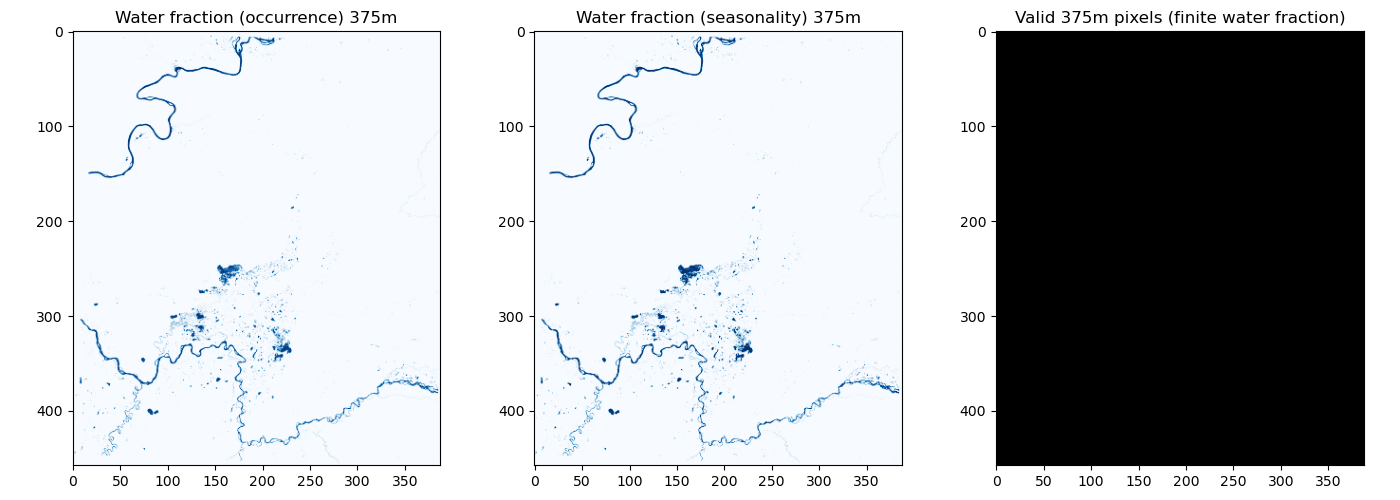

Occurrence 375m: min=0.0000, max=0.9844, mean=0.0191
Seasonality 375m: min=0.0000, max=1.0000, mean=0.0204
Valid pixels (finite): 177704 / 177704
(a) Raster shape: 458 rows x 388 cols
(b) 5 example valid (r,c) pixels (finite, with lat/lon and value):
  r=0, c=0, value=0.0000, lat=65.993647, lon=-150.699556
  r=0, c=1, value=0.0000, lat=65.993845, lon=-150.691320
  r=0, c=2, value=0.0000, lat=65.994043, lon=-150.683084
  r=0, c=3, value=0.0000, lat=65.994240, lon=-150.674848
  r=0, c=4, value=0.0000, lat=65.994436, lon=-150.666612
(c) Suggested (r,c) for inspection:
  near-zero (wf<0.01): r=0, c=0, value=0.0000
  mid-range (0.3<=wf<=0.7): r=6, c=145, value=0.6737
  high (wf>0.99): none found


In [ ]:
# =============================================================================
# VALIDATION / QA — minimal plots + valid pixels mask
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

v1 = water_fraction_occurrence_375m
v2 = water_fraction_seasonality_375m

axes[0].imshow(v1, cmap="Blues", vmin=0, vmax=1)
axes[0].set_title("Water fraction (occurrence) 375m")
axes[1].imshow(v2, cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("Water fraction (seasonality) 375m")

# Valid 375m pixels (finite water fraction) — where inspection is meaningful
valid_mask = np.isfinite(v1)
axes[2].imshow(valid_mask, cmap="binary", vmin=0, vmax=1)
axes[2].set_title("Valid 375m pixels (finite water fraction)")
plt.tight_layout()
plt.show()

valid1 = np.isfinite(v1)
valid2 = np.isfinite(v2)
print("Occurrence 375m: min={:.4f}, max={:.4f}, mean={:.4f}".format(
    np.nanmin(v1) if valid1.any() else np.nan,
    np.nanmax(v1) if valid1.any() else np.nan,
    np.nanmean(v1) if valid1.any() else np.nan))
print("Seasonality 375m: min={:.4f}, max={:.4f}, mean={:.4f}".format(
    np.nanmin(v2) if valid2.any() else np.nan,
    np.nanmax(v2) if valid2.any() else np.nan,
    np.nanmean(v2) if valid2.any() else np.nan))
print("Valid pixels (finite): {:.0f} / {}".format(valid_mask.sum(), valid_mask.size))

def print_suggested_inspection_pixels(wf_375m, transform, crs):
    """Print raster shape, 5 example valid pixels, and suggested (r,c) for inspection."""
    h, w = wf_375m.shape
    print("(a) Raster shape:", h, "rows x", w, "cols")
    finite = np.isfinite(wf_375m)
    rows, cols = np.where(finite)
    if len(rows) == 0:
        print("No finite pixels.")
        return
    trans = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
    n = min(5, len(rows))
    print("(b) 5 example valid (r,c) pixels (finite, with lat/lon and value):")
    for i in range(n):
        r, c = rows[i], cols[i]
        x = transform.c + (c + 0.5) * transform.a
        y = transform.f + (r + 0.5) * transform.e
        lon, lat = trans.transform(x, y)
        val = wf_375m[r, c]
        print(f"  r={r}, c={c}, value={val:.4f}, lat={lat:.6f}, lon={lon:.6f}")
    def _pf(m):
        rc = np.where(m)
        return (int(rc[0][0]), int(rc[1][0])) if rc[0].size > 0 else None
    land = finite & (wf_375m < 0.01)
    mixed = finite & (wf_375m >= 0.3) & (wf_375m <= 0.7)
    water = finite & (wf_375m > 0.99)
    print("(c) Suggested (r,c) for inspection:")
    for label, rc in [("near-zero (wf<0.01)", _pf(land)), ("mid-range (0.3<=wf<=0.7)", _pf(mixed)), ("high (wf>0.99)", _pf(water))]:
        if rc is not None:
            val = wf_375m[rc[0], rc[1]]
            print(f"  {label}: r={rc[0]}, c={rc[1]}, value={val:.4f}")
        else:
            print(f"  {label}: none found")

print_suggested_inspection_pixels(v1, ref_transform, utm_crs)



OCC vs SEA at same (r,c) — pixels chosen from OCCURRENCE (v1)
------------------------------------------------------------------------------------------
label       r    c        lat        lon   occ_375m   sea_375m delta(sea-occ)
------------------------------------------------------------------------------------------
LAND        0    0  65.993647 -150.699556     0.0000     0.0000        +0.0000
MIXED       6  145  65.997603 -149.502097     0.6737     0.8318        +0.1581
MIXED       7  167  65.997088 -149.320353     0.4205     0.4130        -0.0075
MIXED       7  168  65.997213 -149.312106     0.4696     0.3464        -0.1232
MIXED       7  185  65.999255 -149.171890     0.3835     0.5314        +0.1479
MIXED       7  186  65.999371 -149.163641     0.6409     0.6892        +0.0484
WATER      59   77  65.809651 -150.041434     0.9844     1.0000        +0.0156
------------------------------------------------------------------------------------------

--- LAND pixel (r=0, c=0) — OCCUR

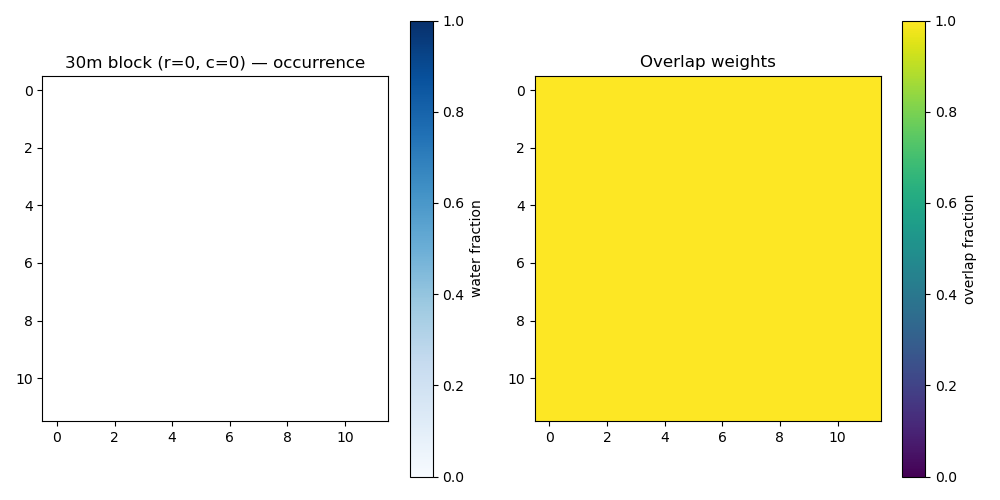


--- LAND pixel (r=0, c=0) — SEASONALITY raster ---
Pixel (r=0, c=0) — raster: seasonality
Center UTM: x=332126.19, y=7324155.21
Center lat/lon: 65.993647, -150.699556
Stored 375m value:         0.000000
Recomputed area-weighted:  0.000000
Total overlap (denominator): 143.997293


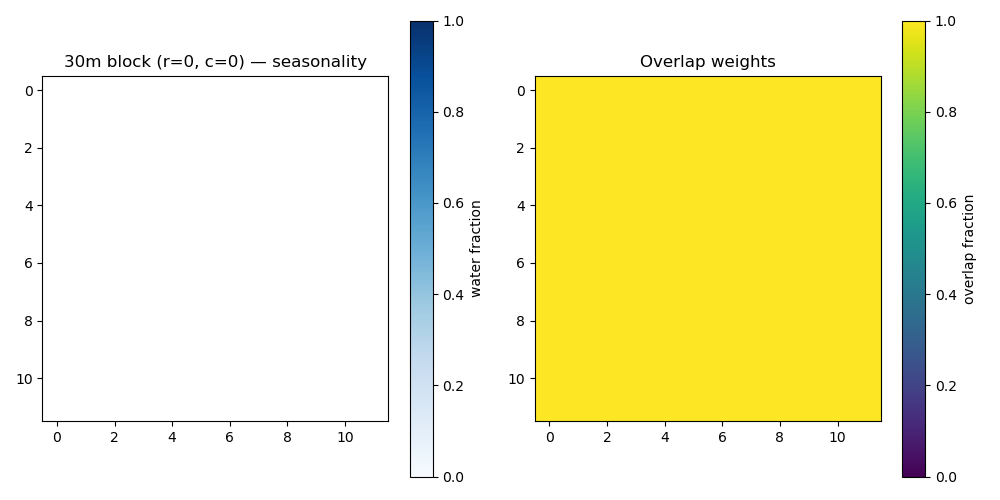


--- MIXED pixel (r=6, c=145) — OCCURRENCE raster ---
Pixel (r=6, c=145) — raster: occurrence
Center UTM: x=386451.88, y=7321908.29
Center lat/lon: 65.997603, -149.502097
Stored 375m value:         0.673716
Recomputed area-weighted:  0.673716
Total overlap (denominator): 133.041358


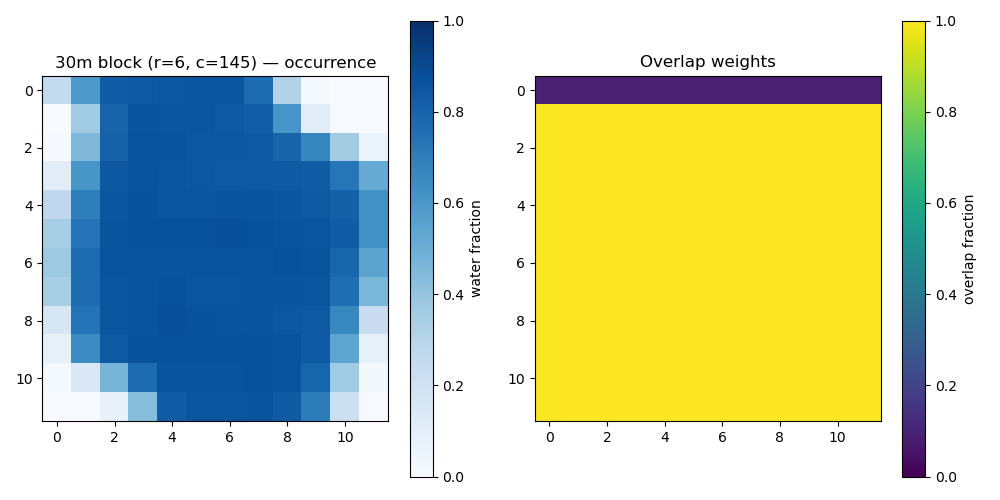


--- MIXED pixel (r=6, c=145) — SEASONALITY raster ---
Pixel (r=6, c=145) — raster: seasonality
Center UTM: x=386451.88, y=7321908.29
Center lat/lon: 65.997603, -149.502097
Stored 375m value:         0.831849
Recomputed area-weighted:  0.831849
Total overlap (denominator): 133.041358


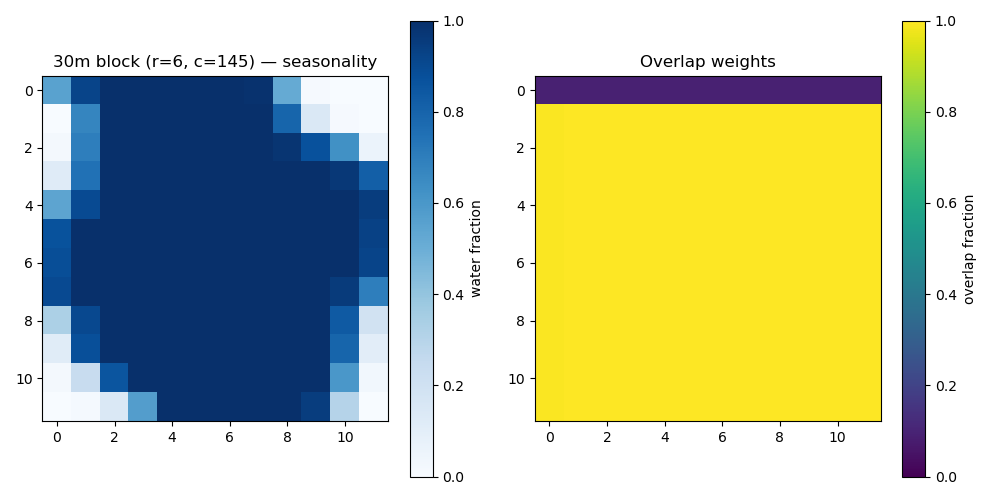


--- MIXED pixel (r=7, c=167) — OCCURRENCE raster ---
Pixel (r=7, c=167) — raster: occurrence
Center UTM: x=394694.40, y=7321533.80
Center lat/lon: 65.997088, -149.320353
Stored 375m value:         0.420510
Recomputed area-weighted:  0.420510
Total overlap (denominator): 130.247846


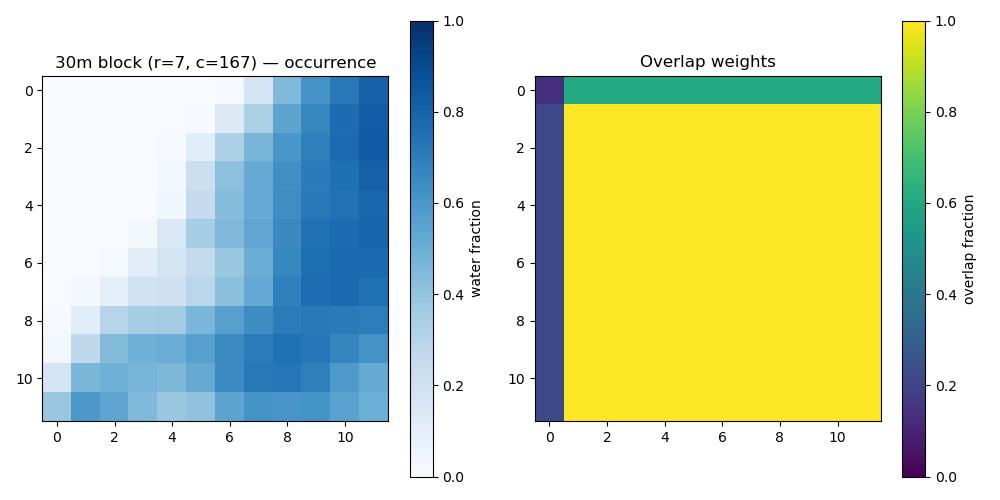


--- MIXED pixel (r=7, c=167) — SEASONALITY raster ---
Pixel (r=7, c=167) — raster: seasonality
Center UTM: x=394694.40, y=7321533.80
Center lat/lon: 65.997088, -149.320353
Stored 375m value:         0.413036
Recomputed area-weighted:  0.413036
Total overlap (denominator): 130.247846


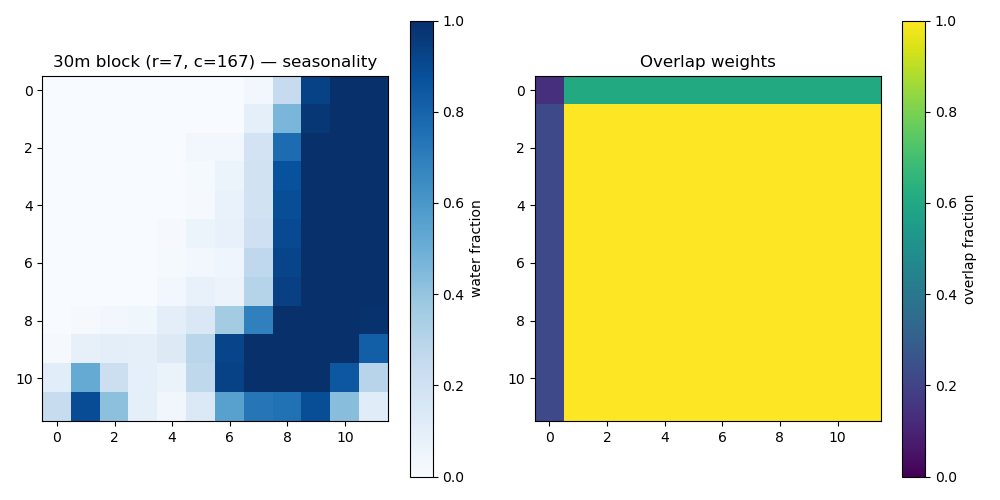


--- MIXED pixel (r=7, c=168) — OCCURRENCE raster ---
Pixel (r=7, c=168) — raster: occurrence
Center UTM: x=395069.06, y=7321533.80
Center lat/lon: 65.997213, -149.312106
Stored 375m value:         0.469553
Recomputed area-weighted:  0.469553
Total overlap (denominator): 136.170933


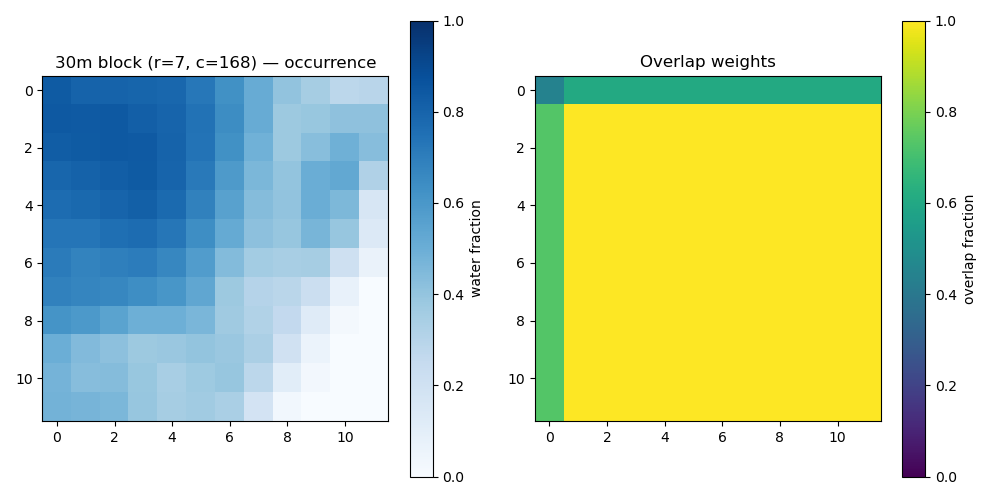


--- MIXED pixel (r=7, c=168) — SEASONALITY raster ---
Pixel (r=7, c=168) — raster: seasonality
Center UTM: x=395069.06, y=7321533.80
Center lat/lon: 65.997213, -149.312106
Stored 375m value:         0.346400
Recomputed area-weighted:  0.346400
Total overlap (denominator): 136.170933


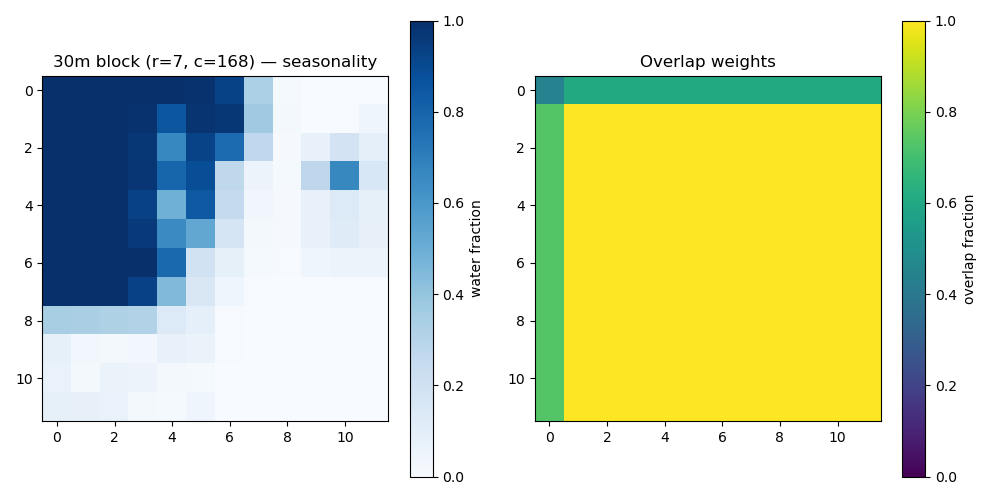


--- MIXED pixel (r=7, c=185) — OCCURRENCE raster ---
Pixel (r=7, c=185) — raster: occurrence
Center UTM: x=401438.28, y=7321533.80
Center lat/lon: 65.999255, -149.171890
Stored 375m value:         0.383528
Recomputed area-weighted:  0.383528
Total overlap (denominator): 132.401783


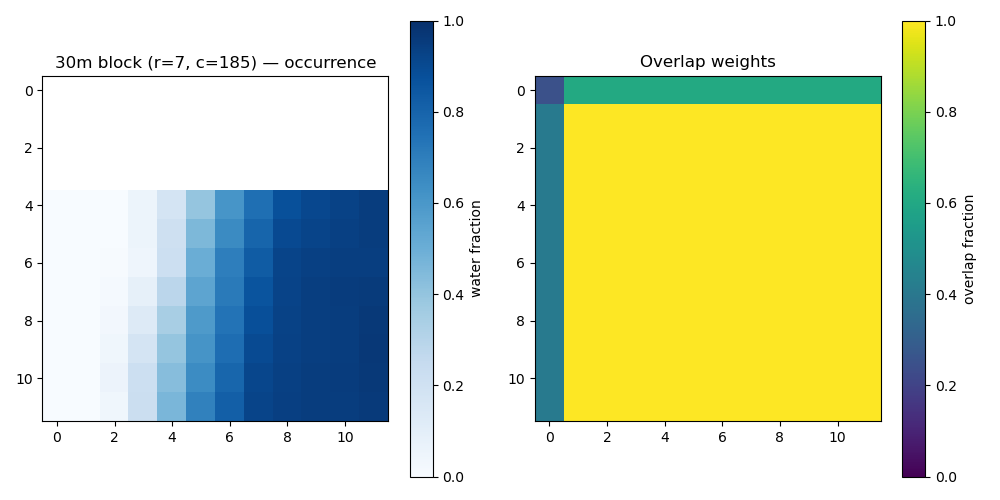


--- MIXED pixel (r=7, c=185) — SEASONALITY raster ---
Pixel (r=7, c=185) — raster: seasonality
Center UTM: x=401438.28, y=7321533.80
Center lat/lon: 65.999255, -149.171890
Stored 375m value:         0.531445
Recomputed area-weighted:  0.531445
Total overlap (denominator): 132.401783


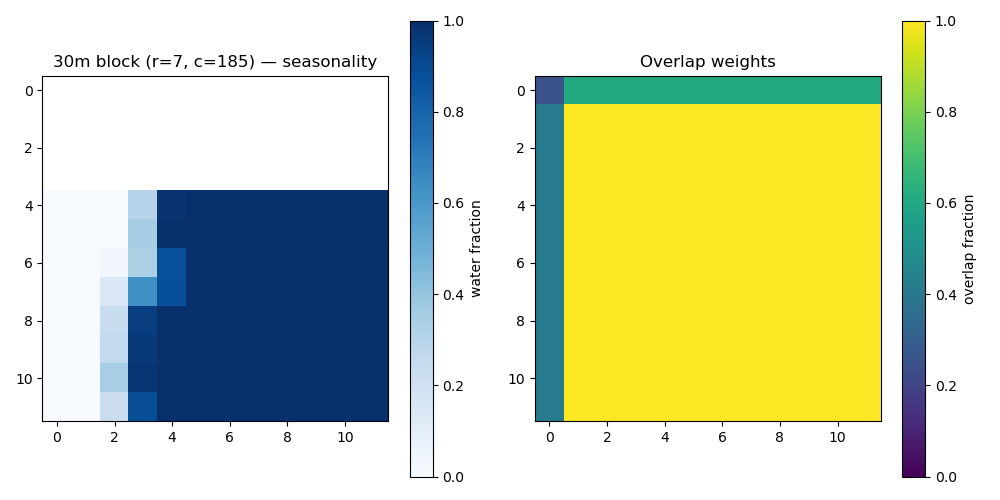


--- MIXED pixel (r=7, c=186) — OCCURRENCE raster ---
Pixel (r=7, c=186) — raster: occurrence
Center UTM: x=401812.94, y=7321533.80
Center lat/lon: 65.999371, -149.163641
Stored 375m value:         0.640866
Recomputed area-weighted:  0.640866
Total overlap (denominator): 138.324870


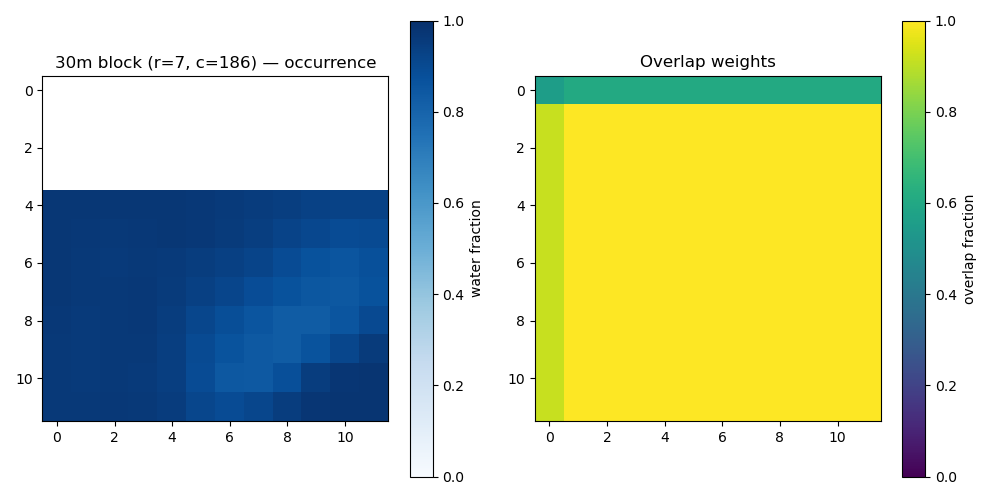


--- MIXED pixel (r=7, c=186) — SEASONALITY raster ---
Pixel (r=7, c=186) — raster: seasonality
Center UTM: x=401812.94, y=7321533.80
Center lat/lon: 65.999371, -149.163641
Stored 375m value:         0.689248
Recomputed area-weighted:  0.689248
Total overlap (denominator): 138.324870


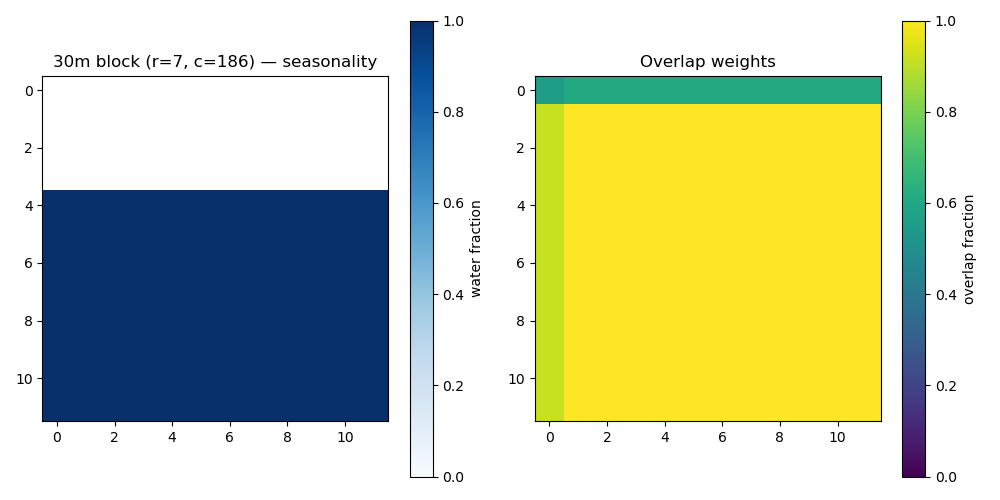


--- WATER pixel (r=59, c=77) — OCCURRENCE raster ---
Pixel (r=59, c=77) — raster: occurrence
Center UTM: x=360975.01, y=7302060.43
Center lat/lon: 65.809651, -150.041434
Stored 375m value:         0.984417
Recomputed area-weighted:  0.984417
Total overlap (denominator): 128.767444


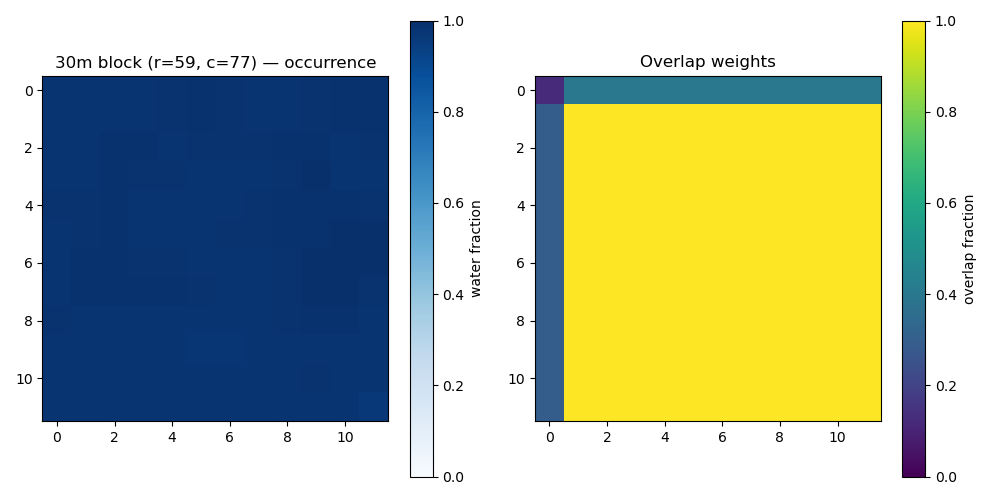


--- WATER pixel (r=59, c=77) — SEASONALITY raster ---
Pixel (r=59, c=77) — raster: seasonality
Center UTM: x=360975.01, y=7302060.43
Center lat/lon: 65.809651, -150.041434
Stored 375m value:         1.000000
Recomputed area-weighted:  1.000000
Total overlap (denominator): 128.767444


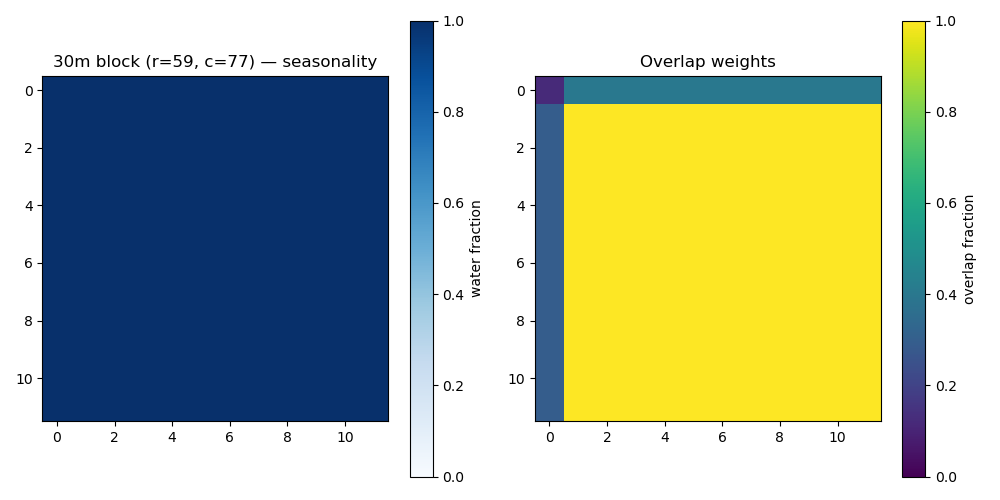

In [ ]:
# =============================================================================
# Compare OCC vs SEA at same inspected pixels
# =============================================================================
# Pixels chosen from OCCURRENCE-derived aggregation (v1 = water_fraction_occurrence_375m).
# We inspect BOTH occurrence and seasonality rasters at those SAME (r,c).

# Paths for occurrence vs seasonality (no file overwriting)
path_occ_375 = os.path.join(OUTPUT_DIR, "water_fraction_occurrence_375m.tif")
path_sea_375 = os.path.join(OUTPUT_DIR, "water_fraction_seasonality_375m.tif")
path_occ_30 = os.path.join(OUTPUT_DIR, "jrc_utm_30m_occurrence.tif")
path_sea_30 = os.path.join(OUTPUT_DIR, "jrc_utm_30m_seasonality.tif")

# Reuse occurrence-based pixel selection (v1 from VALIDATION cell)
pixels_occ = pick_n_pixels_by_class(v1, n_land=N_PIXELS_LAND, n_mixed=N_PIXELS_MIXED, n_water=N_PIXELS_WATER)

# Fallbacks if a class has no pixels
finite = np.isfinite(v1)
if not np.any(finite):
    raise ValueError("No valid (finite) pixels in v1. Check coverage/extent.")
wf_finite = np.where(finite, v1, np.nan)
r_min, c_min = np.unravel_index(np.nanargmin(wf_finite), v1.shape)
r_max, c_max = np.unravel_index(np.nanargmax(wf_finite), v1.shape)
has_land = any(p[0] == "LAND" for p in pixels_occ)
has_mixed = any(p[0] == "MIXED" for p in pixels_occ)
has_water = any(p[0] == "WATER" for p in pixels_occ)
if not has_land:
    pixels_occ.append(("LAND", (int(r_min), int(c_min))))
if not has_mixed:
    pixels_occ.append(("MIXED", (int(r_max), int(c_max))))
if not has_water:
    pixels_occ.append(("WATER", (int(r_max), int(c_max))))

def rc_to_latlon(r, c, transform, crs):
    cx = transform.c + (c + 0.5) * transform.a
    cy = transform.f + (r + 0.5) * transform.e
    trans = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
    lon, lat = trans.transform(cx, cy)
    return lat, lon

# Build summary table: r, c, lat, lon, occ_value_375m, sea_value_375m, delta(sea-occ)
rows = []
for label, rc in pixels_occ:
    r, c = rc
    lat, lon = rc_to_latlon(r, c, ref_transform, utm_crs)
    occ_val = float(v1[r, c]) if np.isfinite(v1[r, c]) else np.nan
    sea_val = float(v2[r, c]) if np.isfinite(v2[r, c]) else np.nan
    delta = (sea_val - occ_val) if np.isfinite(occ_val) and np.isfinite(sea_val) else np.nan
    rows.append((label, r, c, lat, lon, occ_val, sea_val, delta))

print("OCC vs SEA at same (r,c) — pixels chosen from OCCURRENCE (v1)")
print("-" * 90)
print(f"{'label':<8} {'r':>4} {'c':>4} {'lat':>10} {'lon':>10} {'occ_375m':>10} {'sea_375m':>10} {'delta(sea-occ)':>14}")
print("-" * 90)
for label, r, c, lat, lon, occ_val, sea_val, delta in rows:
    occ_s = f"{occ_val:.4f}" if np.isfinite(occ_val) else "nan"
    sea_s = f"{sea_val:.4f}" if np.isfinite(sea_val) else "nan"
    delta_s = f"{delta:+.4f}" if np.isfinite(delta) else "nan"
    print(f"{label:<8} {r:>4} {c:>4} {lat:>10.6f} {lon:>10.6f} {occ_s:>10} {sea_s:>10} {delta_s:>14}")
print("-" * 90)

# Run inspector twice per pixel: once for occurrence raster, once for seasonality raster
for label, rc in pixels_occ:
    r, c = rc
    print(f"\n--- {label} pixel (r={r}, c={c}) — OCCURRENCE raster ---")
    inspect_375m_pixel_contribution(r, c, path_375=path_occ_375, path_30=path_occ_30, raster_label="occurrence")
    print(f"\n--- {label} pixel (r={r}, c={c}) — SEASONALITY raster ---")
    inspect_375m_pixel_contribution(r, c, path_375=path_sea_375, path_30=path_sea_30, raster_label="seasonality")



WATER not found in this AOI (no wf>0.99 pixels). Fallback to max wf pixel.
Chosen pixels:
  LAND: r=0, c=0, wf=0.0000, lat=65.993647, lon=-150.699556, UTM x=332126.2, y=7324155.2
  MIXED: r=6, c=145, wf=0.6737, lat=65.997603, lon=-149.502097, UTM x=386451.9, y=7321908.3
  MIXED: r=7, c=167, wf=0.4205, lat=65.997088, lon=-149.320353, UTM x=394694.4, y=7321533.8
  MIXED: r=7, c=168, wf=0.4696, lat=65.997213, lon=-149.312106, UTM x=395069.1, y=7321533.8
  MIXED: r=7, c=185, wf=0.3835, lat=65.999255, lon=-149.171890, UTM x=401438.3, y=7321533.8
  MIXED: r=7, c=186, wf=0.6409, lat=65.999371, lon=-149.163641, UTM x=401812.9, y=7321533.8
  WATER: r=59, c=77, wf=0.9844, lat=65.809651, lon=-150.041434, UTM x=360975.0, y=7302060.4

--- Inspecting LAND pixel ---
Pixel (r=0, c=0) — raster: occurrence
Center UTM: x=332126.19, y=7324155.21
Center lat/lon: 65.993647, -150.699556
Stored 375m value:         0.000000
Recomputed area-weighted:  0.000000
Total overlap (denominator): 143.997293


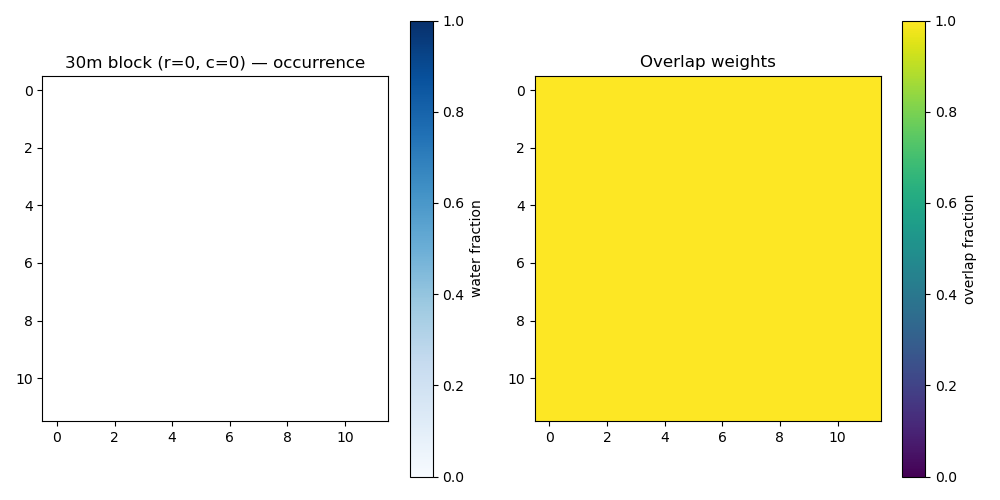


--- Inspecting MIXED pixel ---
Pixel (r=6, c=145) — raster: occurrence
Center UTM: x=386451.88, y=7321908.29
Center lat/lon: 65.997603, -149.502097
Stored 375m value:         0.673716
Recomputed area-weighted:  0.673716
Total overlap (denominator): 133.041358


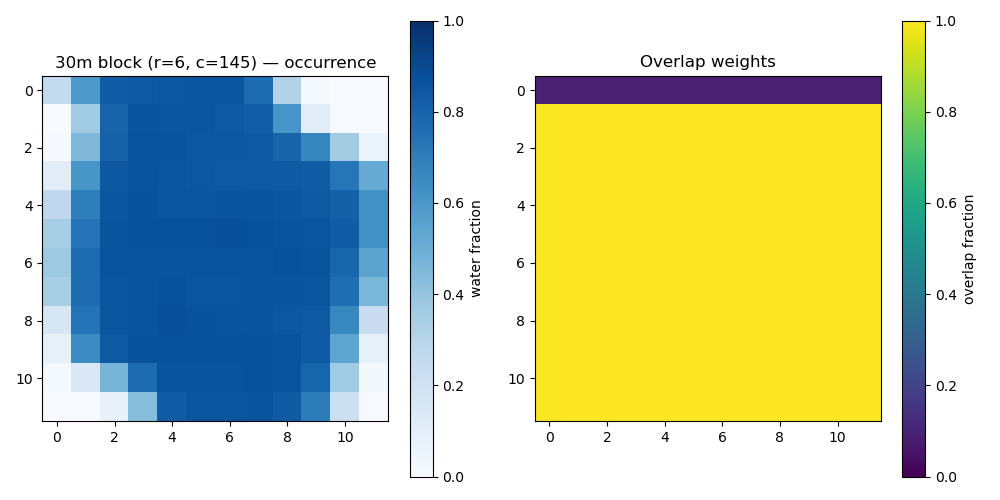


--- Inspecting MIXED pixel ---
Pixel (r=7, c=167) — raster: occurrence
Center UTM: x=394694.40, y=7321533.80
Center lat/lon: 65.997088, -149.320353
Stored 375m value:         0.420510
Recomputed area-weighted:  0.420510
Total overlap (denominator): 130.247846


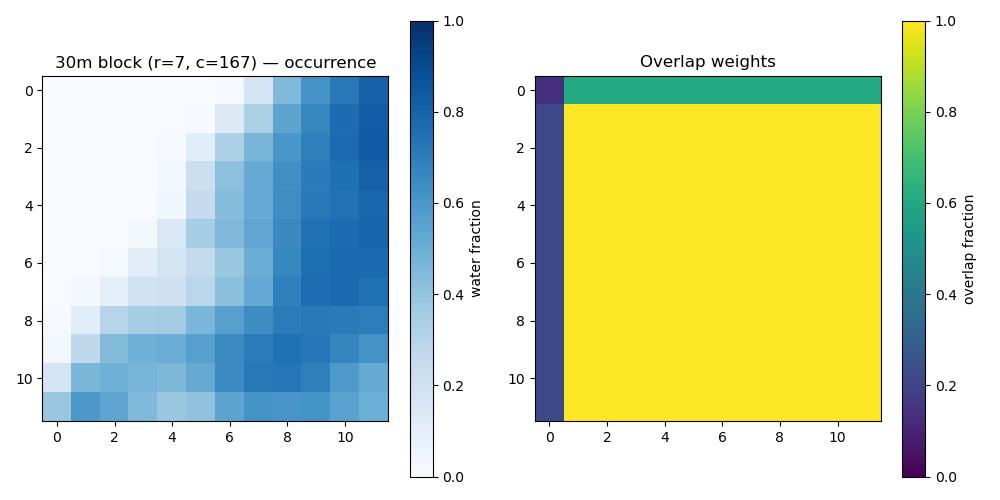


--- Inspecting MIXED pixel ---
Pixel (r=7, c=168) — raster: occurrence
Center UTM: x=395069.06, y=7321533.80
Center lat/lon: 65.997213, -149.312106
Stored 375m value:         0.469553
Recomputed area-weighted:  0.469553
Total overlap (denominator): 136.170933


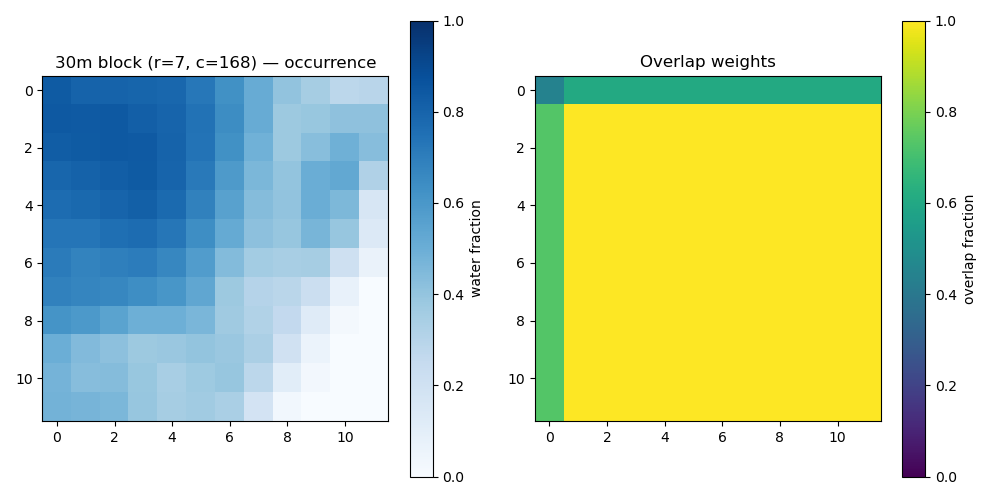


--- Inspecting MIXED pixel ---
Pixel (r=7, c=185) — raster: occurrence
Center UTM: x=401438.28, y=7321533.80
Center lat/lon: 65.999255, -149.171890
Stored 375m value:         0.383528
Recomputed area-weighted:  0.383528
Total overlap (denominator): 132.401783


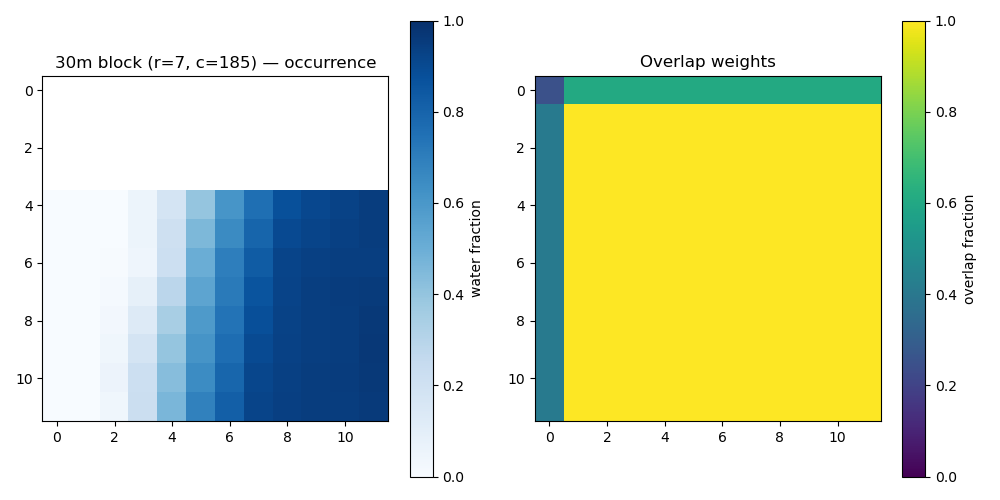


--- Inspecting MIXED pixel ---
Pixel (r=7, c=186) — raster: occurrence
Center UTM: x=401812.94, y=7321533.80
Center lat/lon: 65.999371, -149.163641
Stored 375m value:         0.640866
Recomputed area-weighted:  0.640866
Total overlap (denominator): 138.324870


C:\Users\daksh\AppData\Local\Temp\ipykernel_27468\13430521.py:145: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 2, figsize=(10, 5))


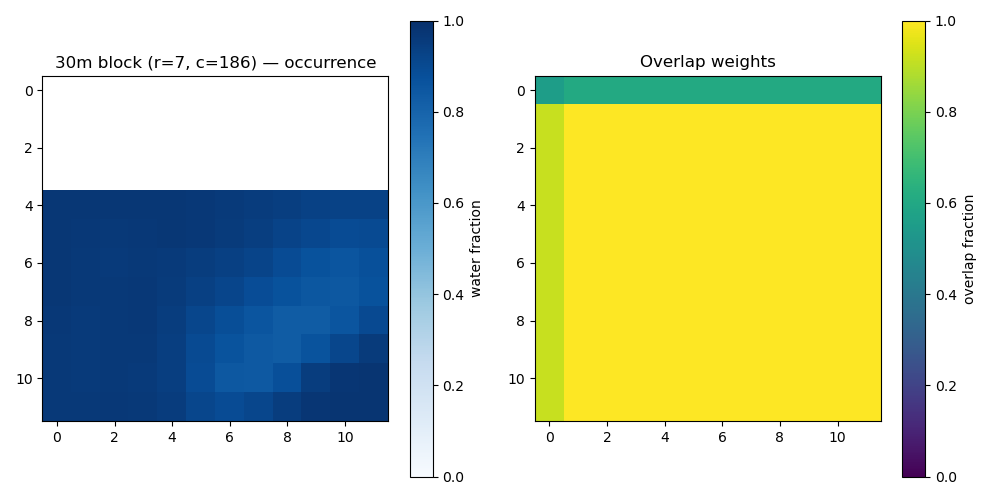


--- Inspecting WATER pixel ---
Pixel (r=59, c=77) — raster: occurrence
Center UTM: x=360975.01, y=7302060.43
Center lat/lon: 65.809651, -150.041434
Stored 375m value:         0.984417
Recomputed area-weighted:  0.984417
Total overlap (denominator): 128.767444


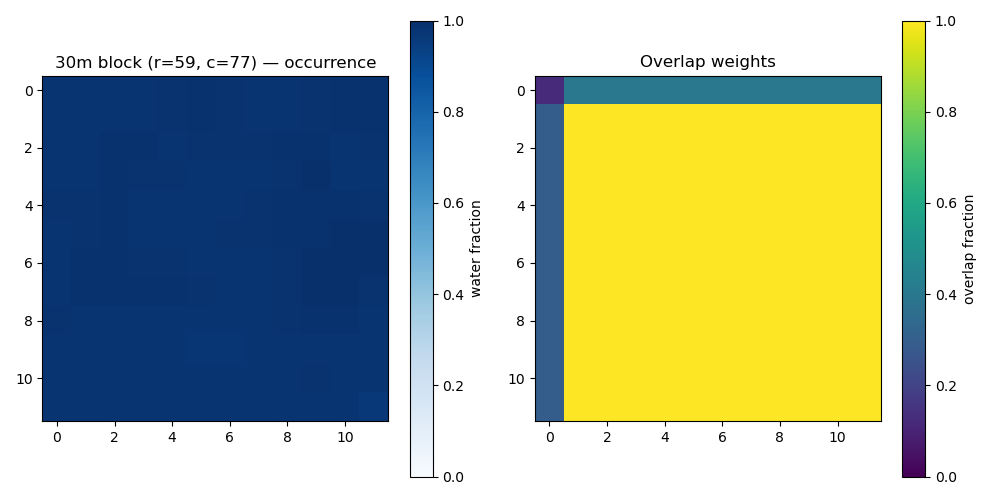

In [ ]:
# =============================================================================
# Run Inspector Examples — automatic pixel selection by class
# =============================================================================
# Load wf_375m from disk (robust if cells run out of order)
path_wf = os.path.join(OUTPUT_DIR, "water_fraction_occurrence_375m.tif")
if not os.path.exists(path_wf):
    raise FileNotFoundError(f"Run pipeline first. Need {path_wf}")

with rasterio.open(path_wf) as src:
    wf = src.read(1).astype(np.float32)
    tf = src.transform
    crs = src.crs
    if src.nodata is not None:
        wf[wf == src.nodata] = np.nan

pixels = pick_n_pixels_by_class(wf, n_land=N_PIXELS_LAND, n_mixed=N_PIXELS_MIXED, n_water=N_PIXELS_WATER)

# Fallback if a class has no pixels
finite = np.isfinite(wf)
if not np.any(finite):
    raise ValueError("No valid (finite) pixels in wf_375m. Check coverage/extent.")

wf_finite = np.where(finite, wf, np.nan)
r_min, c_min = np.unravel_index(np.nanargmin(wf_finite), wf.shape)
r_max, c_max = np.unravel_index(np.nanargmax(wf_finite), wf.shape)

has_land = any(p[0] == "LAND" for p in pixels)
has_mixed = any(p[0] == "MIXED" for p in pixels)
has_water = any(p[0] == "WATER" for p in pixels)
if not has_land:
    pixels.append(("LAND", (int(r_min), int(c_min))))
    print("LAND not found (no wf<0.01); fallback to min wf pixel")
if not has_mixed:
    pixels.append(("MIXED", (int(r_max), int(c_max))))
    print("MIXED not found (no 0.3<wf<0.7); fallback to max wf pixel")
if not has_water:
    pixels.append(("WATER", (int(r_max), int(c_max))))
    print("WATER not found in this AOI (no wf>0.99 pixels). Fallback to max wf pixel.")

def rc_to_latlon(r, c, transform, crs):
    cx = transform.c + (c + 0.5) * transform.a
    cy = transform.f + (r + 0.5) * transform.e
    trans = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
    lon, lat = trans.transform(cx, cy)
    return lat, lon, cx, cy

print("Chosen pixels:")
for label, rc in pixels:
    r, c = rc
    val = wf[r, c]
    lat, lon, cx, cy = rc_to_latlon(r, c, tf, crs)
    print(f"  {label}: r={r}, c={c}, wf={val:.4f}, lat={lat:.6f}, lon={lon:.6f}, UTM x={cx:.1f}, y={cy:.1f}")

# Run inspector for each pixel
for label, rc in pixels:
    print(f"\n--- Inspecting {label} pixel ---")
    inspect_375m_pixel_contribution(rc[0], rc[1])

